# Model Parameters

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from pathlib import Path
import subprocess, h5py, os, time as _time
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# â”€â”€ USER CONTROL: change this to sweep the resolution limit â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
scatterer_spacing_m = 0.20   # lateral separation between two PEC scatterers [m]
                              # try: 0.20, 0.15, 0.10, 0.08, 0.06, 0.04
# â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

# Medium
eps_r      = 3.15
v_ice      = 0.299792458 / np.sqrt(eps_r)   # m/ns  â‰ˆ 0.16892
f_c_GHz    = 1.5                             # centre frequency [GHz]
wavelength = v_ice / f_c_GHz                 # m  â‰ˆ 0.1126
v_mig      = v_ice / 2                       # exploding-reflector half-velocity [m/ns]
t0_ns      = 0.953                           # gprMax Ricker peak delay [ns]

# gprMax grid (30 cells per min wavelength in ice)
dx_grid = 7.454e-4   # m  = 0.7454 mm

# Simulation domain (2D TMy: dy = dx_grid exactly â€” one cell thick)
domain_x    = 4.0    # m
domain_z    = 0.8    # m
time_window = 15e-9  # s

# Zero-offset B-scan survey
x_survey_start = 0.5    # m  (first trace midpoint)
x_survey_end   = 3.5    # m  (last  trace midpoint)
n_cells_step   = 15     # grid cells per trace â†’ spacing â‰ˆ Î»/10
trace_spacing  = n_cells_step * dx_grid           # m  â‰ˆ 0.01118
n_traces = int(round((x_survey_end - x_survey_start) / trace_spacing)) + 1
x_traces = x_survey_start + np.arange(n_traces) * trace_spacing   # [m]

# Scatterer targets
x_s1   = 2.0
x_s2   = x_s1 + scatterer_spacing_m
z_scat = 0.5   # depth of both scatterers [m]

# Migration image grid
x_img = np.linspace(x_survey_start, x_survey_end, 300)
z_img = np.linspace(0.0, domain_z, 120)

rayleigh_m = wavelength / 2

# Paths
BASE          = Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks')
DATA          = BASE / 'B_Scan_Migration_data'
DATA.mkdir(exist_ok=True)
psf_in_path   = DATA / 'psf_bscan.in'
bg_in_path    = DATA / 'bg_bscan.in'
psf_out_path  = DATA / 'psf_bscan_merged.out'
bg_out_path   = DATA / 'bg_bscan_merged.out'
GPRMAX_PYTHON = r'C:\Users\Administrator\miniconda3\envs\gprMax\python.exe'

print(f'Î»_ice          = {wavelength*1e3:.1f} mm')
print(f'Rayleigh limit = {rayleigh_m*1e3:.1f} mm  (Î»/2)')
print(f'v_ice          = {v_ice:.5f} m/ns,   v_mig = v/2 = {v_mig:.5f} m/ns')

In [12]:
wavelength = v_ice / f_c_GHz
wavelength / 0.002

np.float64(56.304638092048904)

In [13]:
x_scatterer_1 = (2 - wavelength)
x_scatterer_2 = (2 + wavelength)
y_scatterer_1_2 = 0.9 - wavelength * 6 # farfield scatterer depth (to avoid near-field effects)
radius_scatterer = wavelength / 10

# Data Creation

In [14]:
radius_scatterer

np.float64(0.011260927618409782)

In [15]:
(3.9 - 0.100) / 380

0.01

In [143]:
%%writefile resolution_study/background/resolution_background.in

#title: GPR Resolution Study - background
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice


#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 background n
#messages: y

In [134]:
%%writefile resolution_study/study_2lambda/resolution_2lambda.in

#title: GPR Resolution Study - 2 wavelength separation
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

// Two point scatterers (PEC)
#cylinder: 1.887 0.224 0 1.887 0.224 0.002 0.0113 pec
#cylinder: 2.113 0.224 0 2.113 0.224 0.002 0.0113 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 two_point_scatterers_2_lambda n
#messages: y

In [ ]:
f'#cylinder: {} {} 0 {} {} 0.010 0.11 pec'.format(x_scatterer_1, y_scatterer_1_2, x_scatterer_1, y_scatterer_1_2)
f'#cylinder: {} {} 0 {} {} 0.010 0.11 pec'.format(x_scatterer_2, y_scatterer_1_2, x_scatterer_2, y_scatterer_1_2)


#python:
if curr_x == 0.500:
    for i in range(1, 100):
        print('#snapshot: 0 0 0 4.000 0.500 0.0002 0.0002 0.0002 0.0002 {} snapshot{}'.format(i*5e-11, i))
#end_python:

In [1]:
import os
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from gprMax.gprMax import api
from tools.outputfiles_merge import merge_files
from tools.plot_Bscan import get_output_data, mpl_plot

In [135]:

two_lambda_input = r'resolution_study/study_2lambda/resolution_2lambda.in'
api(two_lambda_input, n=1, geometry_only=True)


In [ ]:
# two_lambda_filename  = r'resolution_study/study_2lambda/resolution_2lambda'

# merge_files(two_lambda_filename, removefiles=True)

In [2]:
two_lambda_data  = r'resolution_study/study_2lambda/resolution_2lambda_merged.out'
rxnumber = 1
rxcomponent = 'Ez'

output_two_lambda, dt_two_lambda = get_output_data(two_lambda_data, rxnumber, rxcomponent)

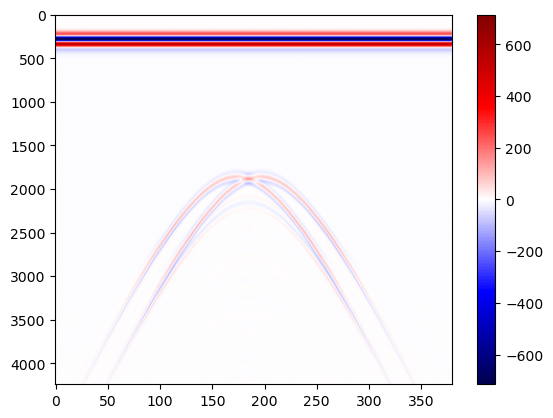

In [3]:
plt.imshow(output_two_lambda, cmap = 'seismic', aspect='auto', vmin=-np.max(np.abs(output_two_lambda)), vmax=np.max(np.abs(output_two_lambda)))
plt.colorbar()

In [4]:

background_input = r'resolution_study/background/resolution_background.in'
api(background_input, n=1, geometry_only=True)



=== Electromagnetic modelling software based on the Finite-Difference Time-Domain (FDTD) method 

    www.gprmax.com   __  __
     __ _ _ __  _ __|  \/  | __ ___  __
    / _` | '_ \| '__| |\/| |/ _` \ \/ /
   | (_| | |_) | |  | |  | | (_| |>  <
    \__, | .__/|_|  |_|  |_|\__,_/_/\_\\
    |___/|_|
                     v3.1.7 (Big Smoke)

 Copyright (C) 2015-2023: The University of Edinburgh
 Authors: Craig Warren and Antonis Giannopoulos

 gprMax is free software: you can redistribute it and/or modify it under the
  terms of the GNU General Public License as published by the Free Software
  Foundation, either version 3 of the License, or (at your option) any later
  version.
 gprMax is distributed in the hope that it will be useful, but WITHOUT ANY
  WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR
  A PARTICULAR PURPOSE.  See the GNU General Public License for more details.
 You should have received a copy of the GNU General Public License along with
  gp

In [ ]:
# background_filename  = r'resolution_study/background/resolution_background'

# merge_files(background_filename, removefiles=True)

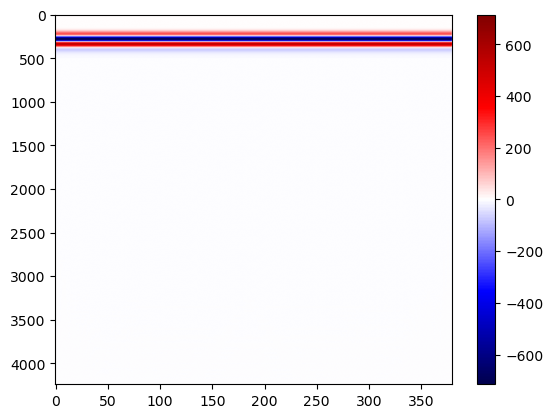

In [5]:
background_data  = r'resolution_study/background/resolution_background_merged.out'
rxnumber = 1
rxcomponent = 'Ez'

output_background, dt_two_lambda = get_output_data(background_data, rxnumber, rxcomponent)
plt.imshow(output_background, cmap = 'seismic', aspect='auto', vmin=-np.max(np.abs(output_background)), vmax=np.max(np.abs(output_background)))
plt.colorbar()

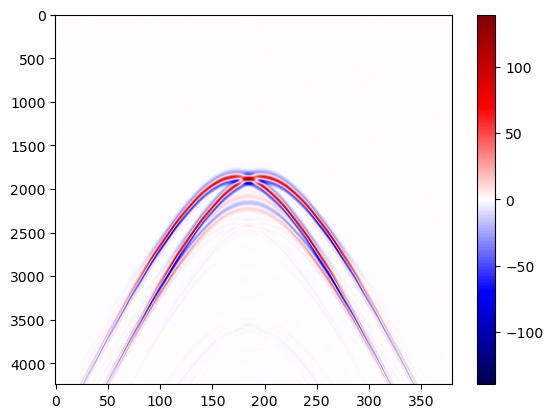

In [6]:
output_two_lambda_no_background = output_two_lambda - output_background
plt.imshow(output_two_lambda_no_background, cmap = 'seismic', aspect='auto', vmin=-np.max(np.abs(output_two_lambda_no_background)), vmax=np.max(np.abs(output_two_lambda_no_background)))
plt.colorbar()

# Loading in the data

In [21]:
def load_gprmax_out(path, component='Ey'):
    """Load gprMax .out HDF5. Returns (bscan, dt_ns, time_ns). Shape: (n_tr, n_t)."""
    with h5py.File(path, 'r') as f:
        dt_s  = float(f.attrs['dt'])
        rxs   = sorted(f['rxs'].keys(), key=lambda s: int(s.replace('rx', '')))
        bscan = np.stack([f['rxs'][r][component][:] for r in rxs], axis=0)
    dt_ns   = dt_s * 1e9
    time_ns = np.arange(bscan.shape[1]) * dt_ns
    return bscan, dt_ns, time_ns


In [22]:
# Resolution Study --- Data Loading + Migration (Kirchhoff, Gazdag, Backprop, LSM)
import io, contextlib
import pylops
from scipy.signal import decimate as _scipy_decimate

wavelength_ice = v_ice / f_c_GHz   # approx 0.1126 m  (1.5 GHz in ice)

STUDY_ROOT = BASE / 'resolution_study'
BG_PATH    = BASE / 'B_Scan_Migration_data' / 'bg_bscan_merged.out'

LAMBDA_FACTORS = [2.0, 1.0, 0.5, 0.25, 0.125, 0.0625]

def _study_dir(factor):
    label = f'{factor:g}'.replace('.', 'p')
    return STUDY_ROOT / f'study_{label}lambda'



# Load shared background (simulated without scatterers)
bscan_bg_rs, _dt_bg, _ = load_gprmax_out(BG_PATH)
print(f'Background B-scan: {bscan_bg_rs.shape}  dt={_dt_bg:.6f} ns')

rs_results = []   # list of dicts per separation

for _factor in LAMBDA_FACTORS:
    _delta = _factor * wavelength_ice
    _xs1 = round((2.0 - _delta / 2) / dx_grid) * dx_grid
    _xs2 = round((2.0 + _delta / 2) / dx_grid) * dx_grid

    _psf_path = _study_dir(_factor) / 'psf_bscan_merged.out'
    print(f'\n{_factor:7g}lambda  Dx={_delta*1e3:.2f} mm  xs1={_xs1:.4f} m  xs2={_xs2:.4f} m')

    if not _psf_path.exists():
        print(f'  WARNING: {_psf_path} not found --- skipping')
        continue

    _full, _dt, _tn = load_gprmax_out(_psf_path)
    _sc = _full - bscan_bg_rs

    rs_results.append(dict(
        factor=_factor, delta_m=_delta,
        xs1=_xs1, xs2=_xs2,
        bscan_sc=_sc, dt_ns=_dt, time_ns=_tn,
    ))
    
print(f'\nLoaded {len(rs_results)} separations.')


NameError: name 'load_gprmax_out' is not defined

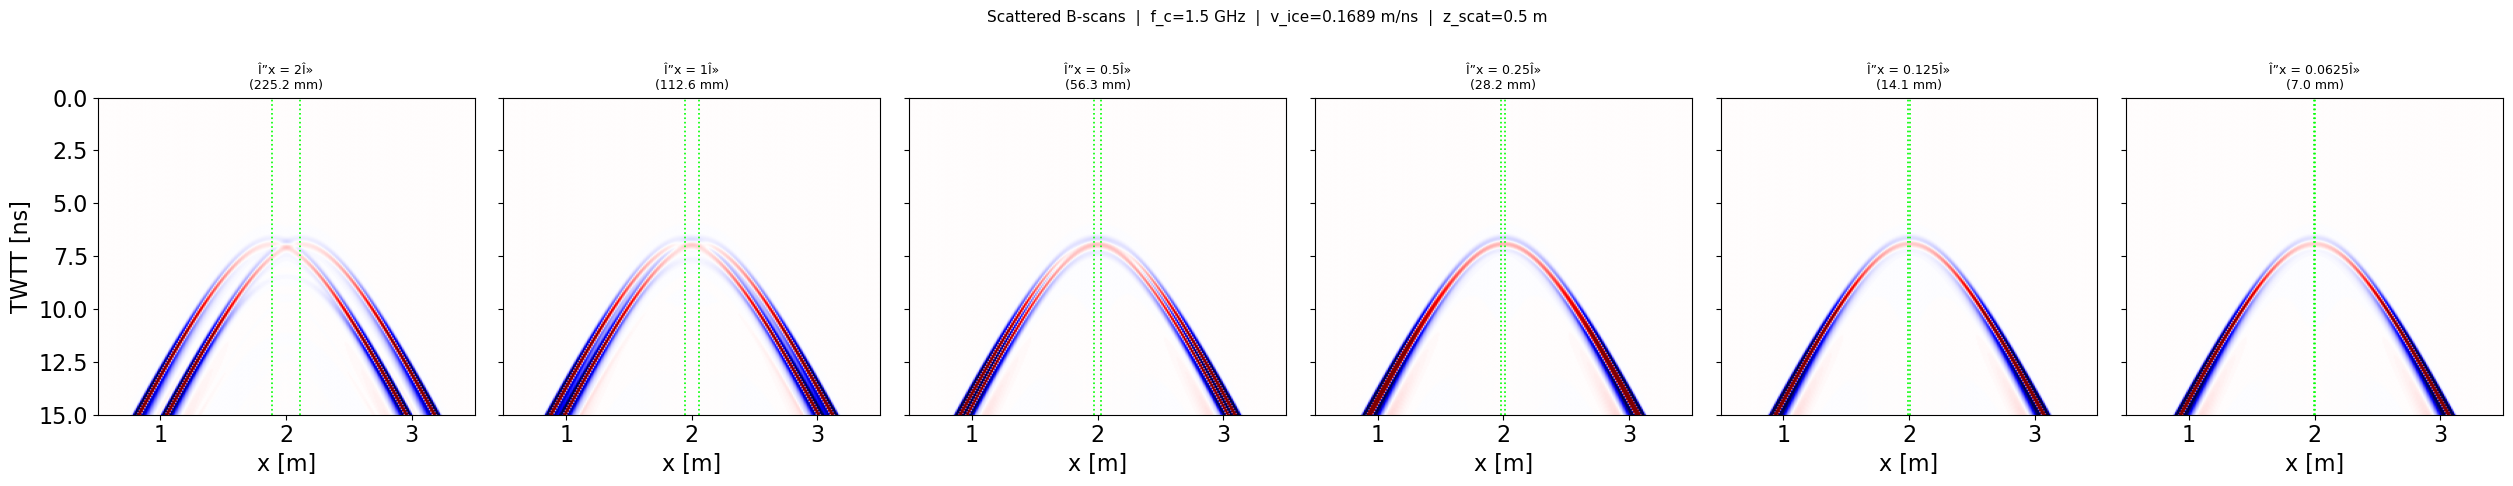

Saved: gallery_bscans.png


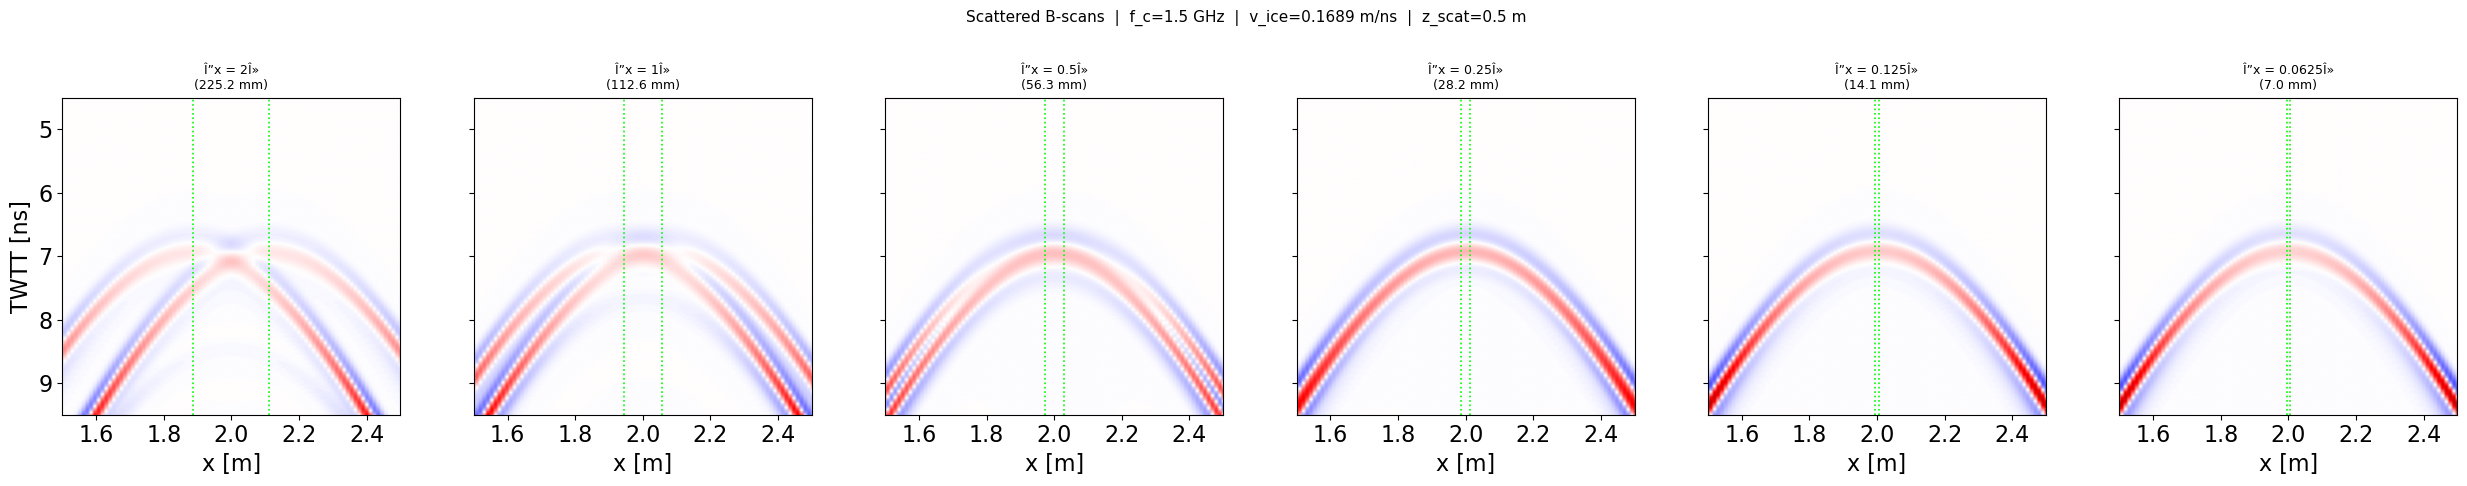

Saved: gallery_bscans_zoomed.png


In [23]:
# Figure 1 â€” B-scan gallery (1 row Ã— N cols, scattered field zoomed)

_n = len(rs_results)
_fig1, _axes1 = plt.subplots(1, _n, figsize=(4.2 * _n, 5), sharey=True)
if _n == 1:
    _axes1 = [_axes1]

for _ax, r in zip(_axes1, rs_results):
    _p = np.percentile(np.abs(r['bscan_sc']), 99)
    _ax.imshow(r['bscan_sc'].T, aspect='auto', cmap='seismic',
               vmin=-_p, vmax=_p,
               extent=[x_traces[0], x_traces[-1], r['time_ns'][-1], 0],
               origin='upper')
    _ax.set_xlim(0.5, 3.5)
    _ax.set_ylim(15, 0)
    _ax.axvline(r['xs1'], color='lime', ls=':', lw=1.2)
    _ax.axvline(r['xs2'], color='lime', ls=':', lw=1.2)
    _ax.set_title(f'Î”x = {r["factor"]:g}Î»\n({r["delta_m"]*1e3:.1f} mm)', fontsize=9)
    _ax.set_xlabel('x [m]')

_axes1[0].set_ylabel('TWTT [ns]')
_fig1.suptitle(
    f'Scattered B-scans  |  f_c={f_c_GHz} GHz  |  v_ice={v_ice:.4f} m/ns  |  z_scat={z_scat} m',
    fontsize=11
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gallery_bscans.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gallery_bscans.png')



# Figure 1 â€” B-scan gallery (1 row Ã— N cols, scattered field zoomed)

_n = len(rs_results)
_fig1, _axes1 = plt.subplots(1, _n, figsize=(4.2 * _n, 5), sharey=True)
if _n == 1:
    _axes1 = [_axes1]

for _ax, r in zip(_axes1, rs_results):
    _p = np.percentile(np.abs(r['bscan_sc']), 99)
    _ax.imshow(r['bscan_sc'].T, aspect='auto', cmap='seismic',
               vmin=-_p, vmax=_p,
               extent=[x_traces[0], x_traces[-1], r['time_ns'][-1], 0],
               origin='upper')
    _ax.set_xlim(1.5, 2.5)
    _ax.set_ylim(9.5, 4.5)
    _ax.axvline(r['xs1'], color='lime', ls=':', lw=1.2)
    _ax.axvline(r['xs2'], color='lime', ls=':', lw=1.2)
    _ax.set_title(f'Î”x = {r["factor"]:g}Î»\n({r["delta_m"]*1e3:.1f} mm)', fontsize=9)
    _ax.set_xlabel('x [m]')

_axes1[0].set_ylabel('TWTT [ns]')
_fig1.suptitle(
    f'Scattered B-scans  |  f_c={f_c_GHz} GHz  |  v_ice={v_ice:.4f} m/ns  |  z_scat={z_scat} m',
    fontsize=11
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gallery_bscans_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gallery_bscans_zoomed.png')



# # Combined gallery: 2 rows Ã— N cols (full + zoom)
# _n = len(rs_results)
# _fig, _axes = plt.subplots(2, _n, figsize=(4.2 * _n, 10), sharex='col')
# if _n == 1:
#     _axes = _axes.reshape(2, 1)

# for j, r in enumerate(rs_results):
#     _p = np.percentile(np.abs(r['bscan_sc']), 99)
#     # top: full
#     ax_top = _axes[0, j]
#     ax_top.imshow(r['bscan_sc'].T, aspect='auto', cmap='seismic',
#                   vmin=-_p, vmax=_p,
#                   extent=[x_traces[0], x_traces[-1], r['time_ns'][-1], 0],
#                   origin='upper')
#     ax_top.set_xlim(0.5, 3.5)
#     ax_top.set_ylim(15, 0)
#     ax_top.axvline(r['xs1'], color='lime', ls=':', lw=1.2)
#     ax_top.axvline(r['xs2'], color='lime', ls=':', lw=1.2)
#     ax_top.set_title(f'Î”x = {r["factor"]:g}Î»\n({r["delta_m"]*1e3:.1f} mm)', fontsize=9)
#     if j == 0:
#         ax_top.set_ylabel('TWTT [ns]')
        

#     # bottom: zoom
#     ax_bot = _axes[1, j]
#     ax_bot.imshow(r['bscan_sc'].T, aspect='auto', cmap='seismic',
#                   vmin=-_p, vmax=_p,
#                   extent=[x_traces[0], x_traces[-1], r['time_ns'][-1], 0],
#                   origin='upper')
#     ax_bot.set_xlim(1.5, 2.5)
#     ax_bot.set_ylim(9.5, 4.5)
#     ax_bot.axvline(r['xs1'], color='lime', ls=':', lw=1.2)
#     ax_bot.axvline(r['xs2'], color='lime', ls=':', lw=1.2)
#     if j == 0:
#         ax_bot.set_ylabel('TWTT [ns]')
#     ax_bot.set_xlabel('x [m]')

# _fig.suptitle(
#     f'Scattered B-scans  |  f_c={f_c_GHz} GHz  |  v_ice={v_ice:.4f} m/ns  |  z_scat={z_scat} m',
#     fontsize=11
# )
# plt.tight_layout()
# plt.savefig(STUDY_ROOT / 'gallery_bscans_combined.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('Saved: gallery_bscans_combined.png')

# Tapering the B-scans

In [18]:

# â”€â”€ Taper parameters â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
taper_end_ns   = 14.0   # cosine ramp at the END of each trace [ns]  â†’  zeros hyperbola tails
taper_decay_ns = 1   # exponential decay time constant [ns]        â†’  emphasises apices

def make_end_taper(n_samples, taper_samples):
    """Unity everywhere, then half-cosine 1â†’0 over the last taper_samples."""
    win = np.ones(n_samples)
    if taper_samples > 0:
        ramp = 0.5 * (1 + np.cos(np.pi * np.arange(taper_samples) / taper_samples))
        win[-taper_samples:] = ramp
    return win

def make_decay_taper(time_ns, tau_ns):
    """Exponential decay: 1.0 at t=0, decays toward 0 with time constant tau_ns."""
    return np.exp(-time_ns / tau_ns)

# â”€â”€ Apply both tapers to every result â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
for r in rs_results:
    n_t   = r['bscan_sc'].shape[1]
    n_tap = int(round(taper_end_ns / r['dt_ns']))

    w_end   = make_end_taper(n_t, n_tap)
    w_decay = make_decay_taper(r['time_ns'], taper_decay_ns)

    r['bscan_end_tapered']   = r['bscan_sc'] * w_end[np.newaxis, :]
    r['bscan_decay_tapered'] = r['bscan_sc'] * w_decay[np.newaxis, :]
    r['bscan_tapered']       = r['bscan_end_tapered']   # alias used by later cells

_ref = rs_results[0]
print(f'End taper   : last {taper_end_ns} ns  ({int(round(taper_end_ns / _ref["dt_ns"]))} samples zeroed)')
print(f'Decay taper : Ï„ = {taper_decay_ns} ns  '
      f'(weight at 0 ns = 1.00,  '
      f'at 6 ns = {np.exp(-6/taper_decay_ns):.2f},  '
      f'at {_ref["time_ns"][-1]:.0f} ns = {np.exp(-_ref["time_ns"][-1]/taper_decay_ns):.3f})')

# â”€â”€ Helper: plot one tapered dataset (full + zoomed) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def _plot_gallery(key, title_tag, fname_stem):
    _n = len(rs_results)
    for xlim, ylim, tag in [((0.5, 3.5), (15, 0), ''),
                             ((1.5, 2.5), (9.5, 4.5), '_zoomed')]:
        fig, axes = plt.subplots(1, _n, figsize=(4.2 * _n, 5), sharey=True)
        if _n == 1:
            axes = [axes]
        for ax, r in zip(axes, rs_results):
            data = r[key]
            _p = np.percentile(np.abs(data), 99)
            ax.imshow(data.T, aspect='auto', cmap='seismic',
                      vmin=-_p, vmax=_p,
                      extent=[x_traces[0], x_traces[-1], r['time_ns'][-1], 0],
                      origin='upper')
            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)
            ax.axvline(r['xs1'], color='lime', ls=':', lw=1.2)
            ax.axvline(r['xs2'], color='lime', ls=':', lw=1.2)
            ax.set_title(f'Î”x = {r["factor"]:g}Î»\n({r["delta_m"]*1e3:.1f} mm)', fontsize=9)
            ax.set_xlabel('x [m]')
        axes[0].set_ylabel('TWTT [ns]')
        zoom_label = ' â€” zoomed' if tag else ''
        fig.suptitle(
            f'{title_tag}{zoom_label}  |  f_c={f_c_GHz} GHz  |  v_ice={v_ice:.4f} m/ns  |  z_scat={z_scat} m',
            fontsize=11
        )
        plt.tight_layout()
        out = STUDY_ROOT / f'{fname_stem}{tag}.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {out.name}')

# â”€â”€ Plot: end taper (zeros hyperbola tails) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
_plot_gallery(
    key        = 'bscan_end_tapered',
    title_tag  = f'End-tapered B-scans  ({taper_end_ns} ns cosine ramp)',
    fname_stem = 'gallery_bscans_end_tapered',
)

# â”€â”€ Plot: time-decay taper (emphasises apices) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
_plot_gallery(
    key        = 'bscan_decay_tapered',
    title_tag  = f'Decay-tapered B-scans  (Ï„ = {taper_decay_ns} ns exponential)',
    fname_stem = 'gallery_bscans_decay_tapered',
)


NameError: name 'rs_results' is not defined

# Kirchhoff Migration

In [7]:
def PylopsKirchoffMigration(data, t, x, vel_model, z,wav='Ricker', wavcenter='Center',f0=0.08 ,recs = None, srcs = None, mode='analytic', dynamic=False,
aperture=None, angleaperture=None, return_op=False):
    """
    Perform Kirchhoff migration using PyLops zero offset operator. pass ns, gHz and meter 
    """
    import numpy as np
    import KirchhoffPylopsZeroOffset
    import importlib
    importlib.reload(KirchhoffPylopsZeroOffset)
    from pylops.utils.wavelets import ricker
    
    # For zero-offset, srcs = recs
    rx = x
    rz = np.zeros_like(rx)
    recs = np.vstack((rx, rz))
    srcs = recs

    # Handle wavelet selection
    if wav == 'Ricker':
        # Generate a short wavelet: 6 cycles, centered at zero, dependent on f0
        n_cycles = 6
        period_ns = 1.0 / f0 # t in ns, f0 in GHz
        wav_duration = n_cycles * period_ns # total duration in ns
        n_wav_samples = int(np.ceil(wav_duration / (t[1] - t[0])))
        # Ensure odd number for center
        if n_wav_samples % 2 == 0:
            n_wav_samples += 1
        wav_arr, trick, wcenter = ricker(t[0:n_wav_samples], f0=f0)
    else:
        wav_arr = wav
        
    if wavcenter == 'Center':
        wavcenter = wcenter

    # Build Zero Offset Kirchhoff operator
    K = KirchhoffPylopsZeroOffset.Kirchhoff(
        z=z, x=x, t=t,
        srcs=srcs, recs=recs,
        vel=vel_model,
        wav=wav_arr, wavcenter=wavcenter,
        mode=mode, dynamic=dynamic,
        aperture=aperture, angleaperture=angleaperture
    )

    d = data.flatten()
    print("d.shape:", d.shape, "K dimension:", K.shape)

    # Migrate: apply adjoint
    m = K.H @ d
    
    # Reshape to (nz, nx)
    m = m.reshape(len(x), len(z)).T
    
    if return_op:
        return m, K
    return m

In [8]:
def kirchhoff_poststack(bscan, dt_ns, x_traces, v_mig, x_img, z_img, t0_ns):
    """
    Post-stack zero-offset Kirchhoff delay-and-sum.

    Image(x, z) = Î£_tr  bscan[tr, t(x, z, x_tr)]
    t = r / v_mig + t0,   r = sqrt((x - x_tr)^2 + z^2)

    Uses linear interpolation between adjacent time samples.
    Returns image (n_z, n_x), normalised to peak = 1.
    """
    n_tr, n_t = bscan.shape
    image = np.zeros((len(z_img), len(x_img)))

    # Aperture / obliquity parameters
    max_angle_deg = 40.0
    tan_max = np.tan(np.radians(max_angle_deg))

    tr_idx = np.arange(n_tr)

    # Perform delay-and-sum with obliquity weighting and aperture limit.
    for iz, z in enumerate(z_img):
        if z == 0.0:
            continue

        dx = x_img[:, None] - x_traces[None, :]     # (n_x, n_tr)
        r  = np.sqrt(dx**2 + z**2)

        # Two-way travel time (using v_mig per docstring)
        t  = r / v_mig + t0_ns                       # (n_x, n_tr) [ns]

        i_frac = t / dt_ns
        i0 = np.clip(i_frac.astype(int), 0, n_t - 2)
        frac = i_frac - i0
        i1 = np.minimum(i0 + 1, n_t - 1)

        # Linear interpolation in time
        samp = ((1 - frac) * bscan[tr_idx[None, :], i0]
               +     frac  * bscan[tr_idx[None, :], i1])  # (n_x, n_tr)

        # Aperture mask: allow only traces within semi-aperture angle
        aperture_mask = (np.abs(dx) <= (z * tan_max)).astype(float)

        # Obliquity factor (cosine of incidence angle)
        obliquity = np.where(r > 0, z / r, 1.0)

        # Apply weights and sum
        samp *= (obliquity * aperture_mask)
        image[iz] = samp.sum(axis=1)

    peak = np.max(np.abs(image))
    return image / (peak + 1e-30)

In [20]:

ANGLE_AP = 40   # half-aperture [degrees] â€” applied identically to both methods

# Shift each trace so the Ricker peak lands at t=0 (required by PyLops)
_t0_samp = int(round(t0_ns / rs_results[0]['dt_ns']))

# â”€â”€ Run both methods on every separation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
for r in rs_results:
    _t = _time.perf_counter()

    # DAS: v_mig = v_ice/2; t0 folded into travel-time formula
    r['kh_das_img'] = kirchhoff_poststack(
        r['bscan_decay_tapered'], r['dt_ns'],
        x_traces, v_mig, x_traces, z_img, t0_ns
    )

    # PyLops: shift data so peak is at t=0, then migrate with full v_ice
    _shifted = np.roll(r['bscan_decay_tapered'], -_t0_samp, axis=1)
    _shifted[:, -_t0_samp:] = 0.0
    r['kh_pylops_img'], r['kh_op'] = PylopsKirchoffMigration(
        _shifted, r['time_ns'], x_traces,
        v_ice, z_img,
        f0=f_c_GHz, angleaperture=ANGLE_AP, return_op=True,
    )

    print(f'  Î”x={r["factor"]:g}Î»  done in {_time.perf_counter()-_t:.1f} s')

print(f'\nDone â€” {len(rs_results)} separations.')


NameError: name 'rs_results' is not defined

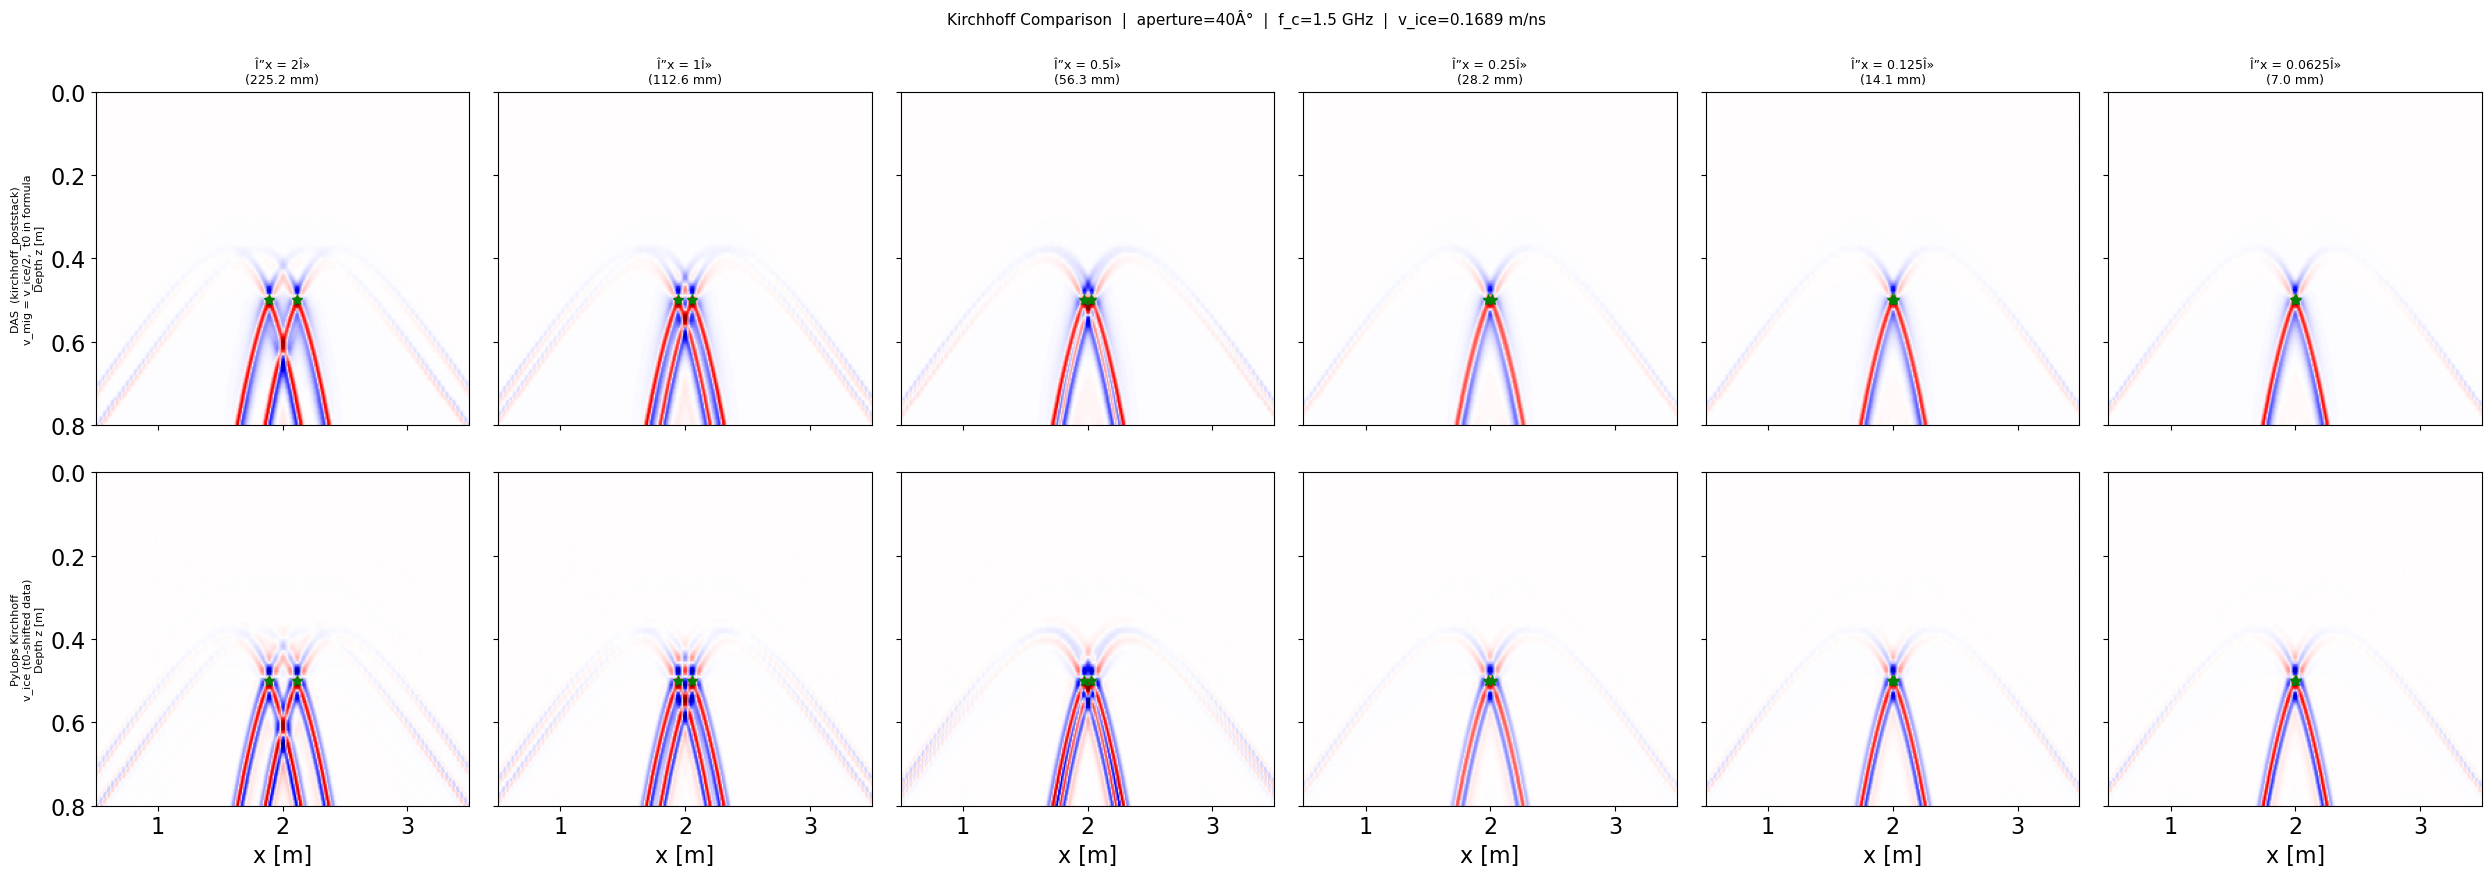

Saved: gallery_kirchhoff_comparison.png


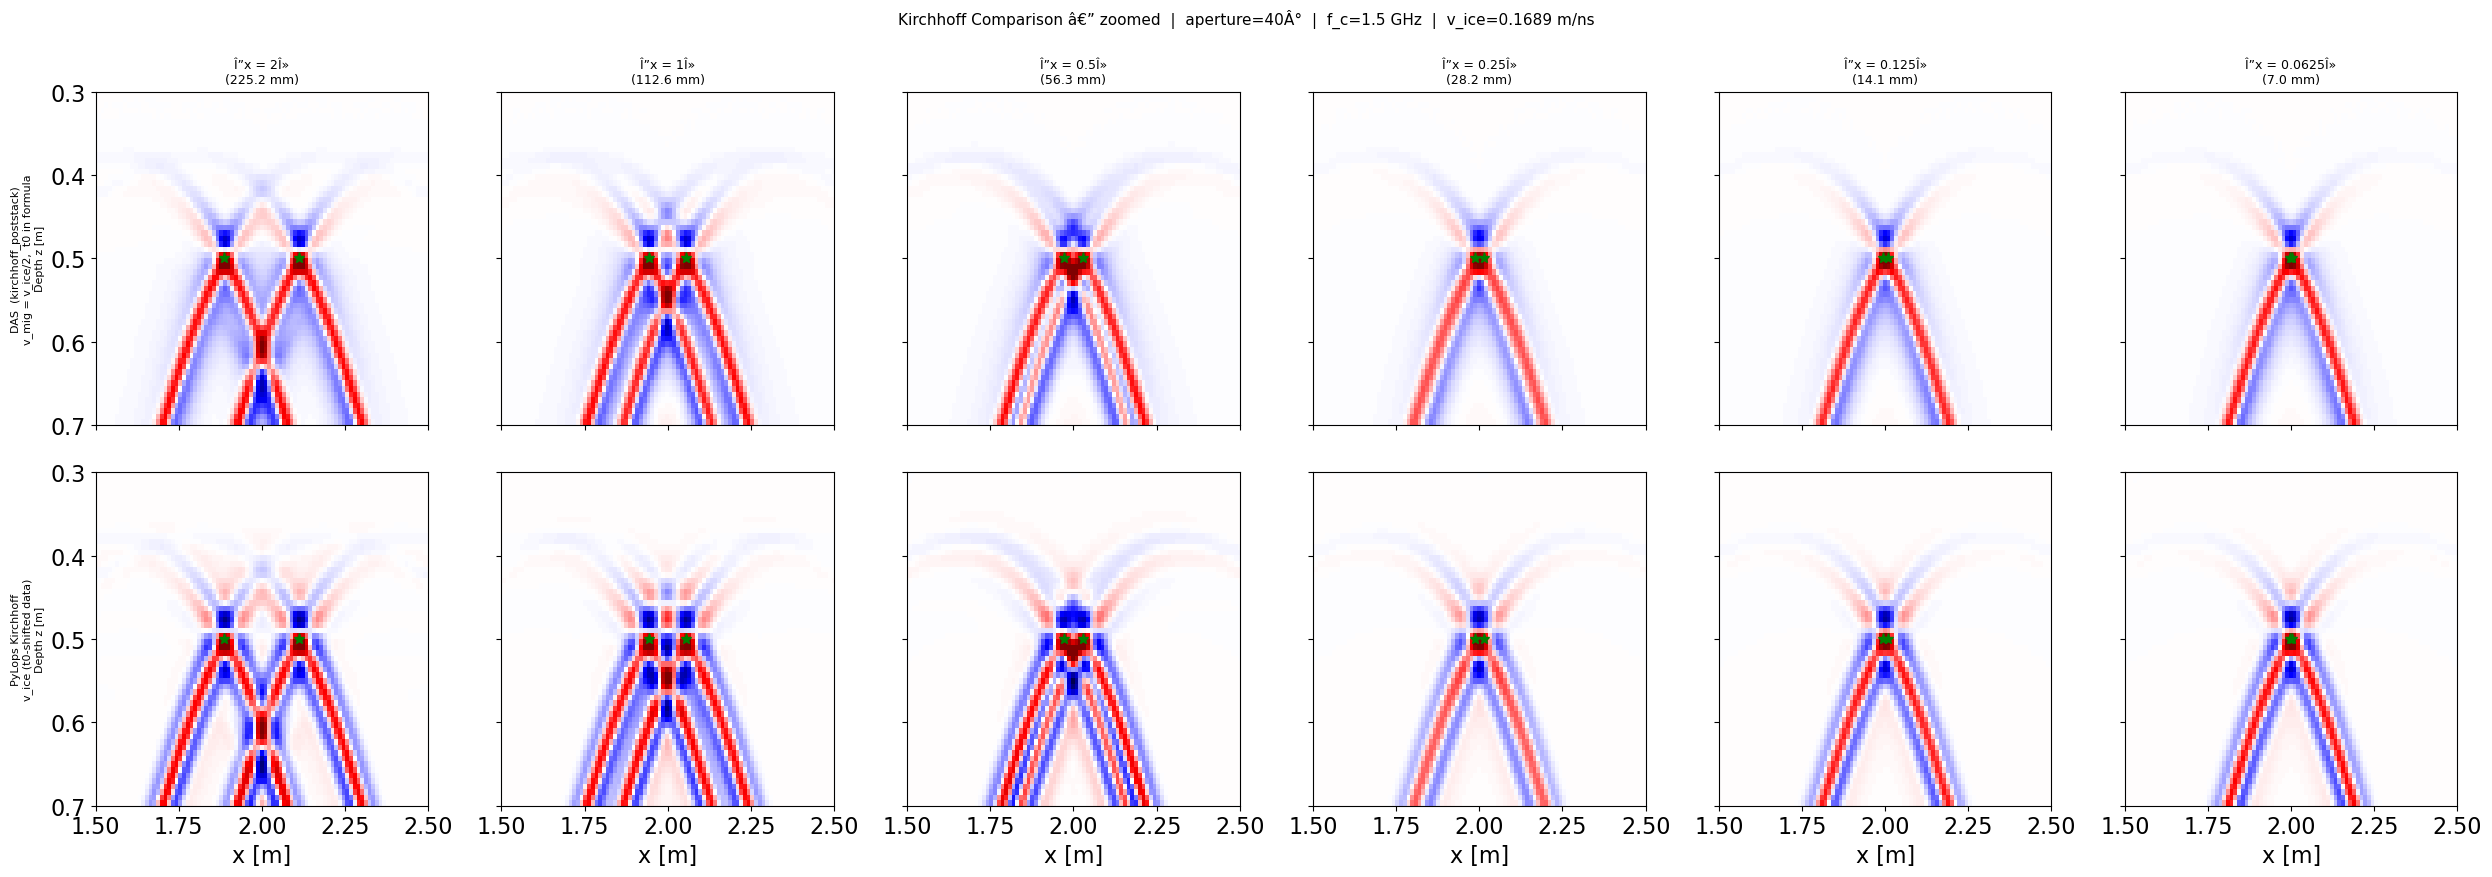

Saved: gallery_kirchhoff_comparison_zoomed.png


In [35]:

# â”€â”€ 2-row comparison gallery â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
_methods = [
    ('kh_das_img',    'DAS  (kirchhoff_poststack)\nv_mig = v_ice/2,  t0 in formula'),
    ('kh_pylops_img', f'PyLops Kirchhoff\nv_ice (t0-shifted data)'),
]

_n = len(rs_results)
for xlim, zlim, tag in [
    ((x_traces[0], x_traces[-1]), (z_img[-1], z_img[0]), ''),
    ((1.5, 2.5), (0.7, 0.3), '_zoomed'),
]:
    fig, axes = plt.subplots(2, _n, figsize=(4.2 * _n, 9), sharey='row', sharex='col')
    if _n == 1:
        axes = axes.reshape(2, 1)

    for row, (key, row_label) in enumerate(_methods):
        for col, r in enumerate(rs_results):
            ax  = axes[row, col]
            img = r[key]
            _p  = np.max(np.abs(img)) * 0.8
            ax.imshow(img, aspect='auto', cmap='seismic',
                      vmin=-_p, vmax=_p,
                      extent=[x_traces[0], x_traces[-1], z_img[-1], z_img[0]],
                      origin='upper')
            ax.set_xlim(*xlim)
            ax.set_ylim(*zlim)
            ax.plot(r['xs1'], z_scat, 'g*', ms=8, zorder=5)
            ax.plot(r['xs2'], z_scat, 'g*', ms=8, zorder=5)
            if row == 0:
                ax.set_title(f'Î”x = {r["factor"]:g}Î»\n({r["delta_m"]*1e3:.1f} mm)', fontsize=9)
            if row == len(_methods) - 1:
                ax.set_xlabel('x [m]')
            if col == 0:
                ax.set_ylabel(f'{row_label}\nDepth z [m]', fontsize=8)

    zoom_label = ' â€” zoomed' if tag else ''
    fig.suptitle(
        f'Kirchhoff Comparison{zoom_label}'
        f'  |  aperture={ANGLE_AP}Â°  |  f_c={f_c_GHz} GHz  |  v_ice={v_ice:.4f} m/ns',
        fontsize=11,
    )
    plt.tight_layout()
    out = STUDY_ROOT / f'gallery_kirchhoff_comparison{tag}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out.name}')


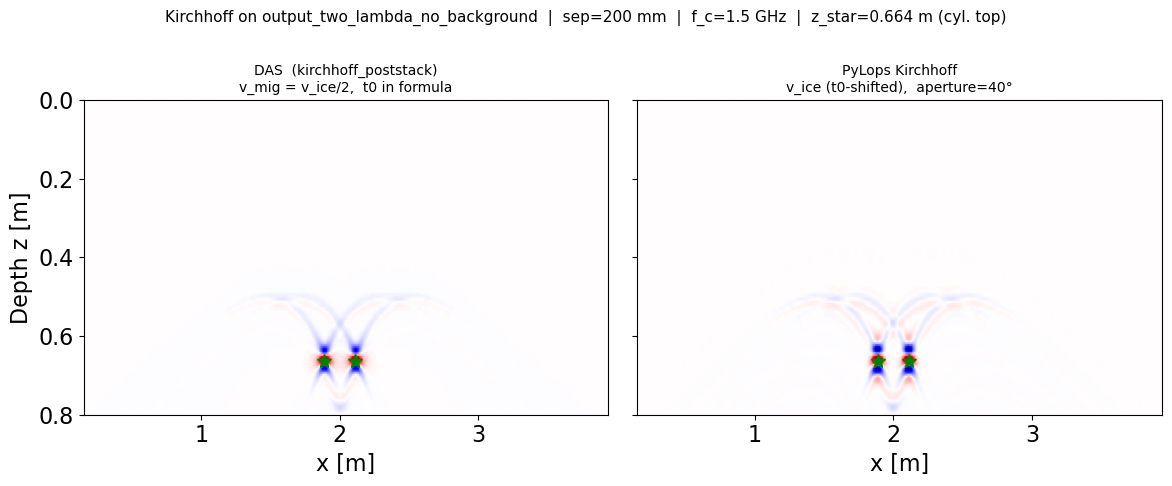

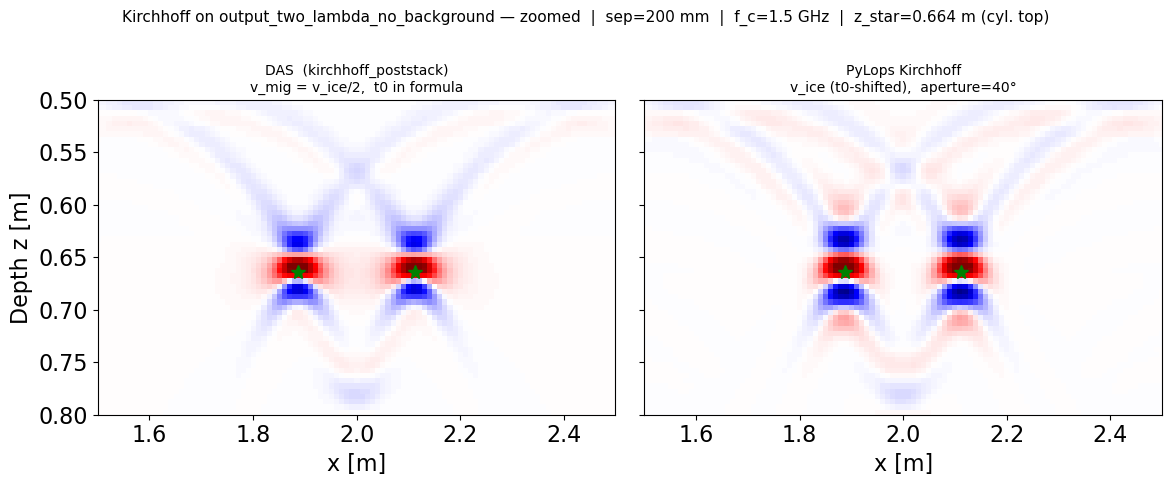

In [23]:
# ── Kirchhoff on output_two_lambda_no_background ──────────────────────────────
_raw = output_two_lambda_no_background
dt_ns_2lam = dt_two_lambda * 1e9   # dt from get_output_data, in seconds

# Normalise to (n_tr, n_t)
if _raw.shape[0] > _raw.shape[1]:
    _data_trnt = _raw.T
else:
    _data_trnt = _raw.copy()

n_tr_2lam, n_t_2lam = _data_trnt.shape
time_ns_2lam = np.arange(n_t_2lam) * dt_ns_2lam

# Bistatic geometry: Tx at curr_x, Rx at curr_x + 0.1 m (from .in file)
# Zero-offset migration requires MIDPOINT positions (apex of bistatic hyperbola
# is at the midpoint, not at the source position).
_rx_offset    = 0.1                      # m  (Rx offset from Tx)
x_traces_2lam = (0.1 + _rx_offset / 2) + np.arange(n_tr_2lam) * 0.01   # midpoints [m]

# Scatterer geometry
z_scat_2lam  = 0.9 - y_scatterer_1_2    # cylinder centre depth [m]
z_star_2lam  = z_scat_2lam - radius_scatterer   # top of cylinder (first reflection) [m]

# depth image grid (0 → 0.8 m covers z_scat_2lam ≈ 0.676 m)
z_img_2lam = np.linspace(0.0, 0.8, 160)

print(f'raw={_raw.shape}  → (n_tr, n_t)={_data_trnt.shape}')
print(f'dt={dt_ns_2lam:.6f} ns,  t_max={time_ns_2lam[-1]:.2f} ns')
print(f'x_traces_2lam (midpoints): {x_traces_2lam[0]:.3f} → {x_traces_2lam[-1]:.3f} m  ({n_tr_2lam} traces)')
print(f'z_scat_2lam (centre) = {z_scat_2lam:.3f} m,  z_star_2lam (top) = {z_star_2lam:.4f} m')

# ── Taper ────────────────────────────────────────────────────────────────────
n_tap_2lam   = int(round(taper_end_ns / dt_ns_2lam))
w_end_2lam   = make_end_taper(n_t_2lam, n_tap_2lam)
w_decay_2lam = make_decay_taper(time_ns_2lam, taper_decay_ns)
_data_tapered = _data_trnt * (w_end_2lam * w_decay_2lam)[np.newaxis, :]

# t0 shift for PyLops
_t0_samp_2lam = int(round(t0_ns / dt_ns_2lam))
_shifted_2lam = np.roll(_data_tapered, -_t0_samp_2lam, axis=1)
_shifted_2lam[:, -_t0_samp_2lam:] = 0.0

# ── DAS Kirchhoff ─────────────────────────────────────────────────────────────
_t = _time.perf_counter()
kh_das_2lam = kirchhoff_poststack(
    _data_tapered, dt_ns_2lam,
    x_traces_2lam, v_mig, x_traces_2lam, z_img_2lam, t0_ns
)
print(f'DAS Kirchhoff: {_time.perf_counter()-_t:.1f} s  shape={kh_das_2lam.shape}')

# ── PyLops Kirchhoff ──────────────────────────────────────────────────────────
_t = _time.perf_counter()
kh_pylops_2lam, _ = PylopsKirchoffMigration(
    _shifted_2lam, time_ns_2lam, x_traces_2lam,
    v_ice, z_img_2lam,
    f0=f_c_GHz, angleaperture=ANGLE_AP, return_op=True,
)
print(f'PyLops Kirchhoff: {_time.perf_counter()-_t:.1f} s  shape={kh_pylops_2lam.shape}')

# ── Plot ─────────────────────────────────────────────────────────────────────
_methods_2lam = [
    (kh_das_2lam,    'DAS  (kirchhoff_poststack)\nv_mig = v_ice/2,  t0 in formula'),
    (kh_pylops_2lam, f'PyLops Kirchhoff\nv_ice (t0-shifted),  aperture={ANGLE_AP}°'),
]

for xlim, zlim, tag in [
    ((x_traces_2lam[0], x_traces_2lam[-1]), (z_img_2lam[-1], z_img_2lam[0]), ''),
    ((1.5, 2.5),                             (0.8, 0.5),                     '_zoomed'),
]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    for ax, (img, label) in zip(axes, _methods_2lam):
        _p = np.max(np.abs(img)) * 0.8
        ax.imshow(img, aspect='auto', cmap='seismic',
                  vmin=-_p, vmax=_p,
                  extent=[x_traces_2lam[0], x_traces_2lam[-1], z_img_2lam[-1], z_img_2lam[0]],
                  origin='upper')
        ax.set_xlim(*xlim)
        ax.set_ylim(*zlim)
        ax.plot(x_scatterer_1, z_star_2lam, 'g*', ms=10, zorder=5)
        ax.plot(x_scatterer_2, z_star_2lam, 'g*', ms=10, zorder=5)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('x [m]')
    axes[0].set_ylabel('Depth z [m]')
    zoom_label = ' — zoomed' if tag else ''
    fig.suptitle(
        f'Kirchhoff on output_two_lambda_no_background{zoom_label}'
        f'  |  sep={scatterer_spacing_m*1e3:.0f} mm  |  f_c={f_c_GHz} GHz'
        f'  |  z_star={z_star_2lam:.3f} m (cyl. top)',
        fontsize=11,
    )
    plt.tight_layout()
    out = STUDY_ROOT / f'kirchhoff_two_lambda_no_bg{tag}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out.name}')


NameError: name 'gazdag_poststack' is not defined

In [177]:
z_scat_2lam

np.float64(0.6756556571045869)

# Gazdag Migration

In [24]:
def gazdag_poststack(bscan, dt_ns, x_traces, v_mig, x_img, z_img, t0_ns,
                     f_min_GHz=0.3, f_max_GHz=3.0):
    """
    Standard Gazdag phase-shift migration for zero-offset post-stack data.

    No source-side correction (unlike CSG shot-profile Gazdag).
    Uses v_mig = v/2 (exploding-reflector half-velocity) in kz.

    Steps:
    1. 2D FFT of tapered bscan (2x spatial zero-padding).
    2. Bandpass to signal frequencies (f_min to f_max GHz) â€” removes
       out-of-band bins that would otherwise dominate the depth sum.
    3. t0 phase correction: D *= exp(+i.omega.t0) to remove Ricker peak delay.
    4. Depth loop: D *= exp(+i.kz.dz),  kz = sqrt((omega/v_mig)^2 - kx^2).
       Evanescent components (kz^2 <= 0) zeroed throughout.
    5. Imaging: image[z] = Re{ IFFT_kx{ sum_omega D } }  (t = 0 condition).
    6. Bilinear interpolation to x_img grid.
    """
    n_tr, n_t = bscan.shape
    dx_tr = float(x_traces[1] - x_traces[0])
    n_pad = 2 * n_tr   # 2x spatial zero-padding
    n_t_pad = 2 * n_t  # 2x temporal zero-padding

    # Spatial cosine taper (5% each edge)
    taper = np.ones(n_tr)
    nb = max(1, int(0.05 * n_tr))
    taper[:nb]  = 0.5 * (1 - np.cos(np.pi * np.arange(nb) / nb))
    taper[-nb:] = taper[:nb][::-1]

    # 2D FFT  ->  shape (n_pad, n_t)
    D = np.fft.fft2(bscan * taper[:, None], s=(n_pad, n_t))
    f_arr  = np.fft.fftfreq(n_t, dt_ns)           # GHz (dt in ns -> f in 1/ns = GHz)
    omega  = 2 * np.pi * f_arr                     # rad/ns
    kx     = 2 * np.pi * np.fft.fftfreq(n_pad, dx_tr)  # rad/m

    # Bandpass: zero frequency bins outside signal band
    band = (np.abs(f_arr) >= f_min_GHz) & (np.abs(f_arr) <= f_max_GHz)
    D[:, ~band] = 0.0
    print(f'  Bandpass: {band.sum()} of {n_t} freq bins kept '
          f'({f_min_GHz}-{f_max_GHz} GHz)')

    # t0 correction: advance phase to align wavelet peak with geometric TWTT
    D *= np.exp(1j * omega[None, :] * t0_ns) 

    # Dispersion with half-velocity (exploding reflector)
    kz2 = (omega[None, :] / v_mig)**2 - kx[:, None]**2  # (n_pad, n_t)
    kz  = np.where(kz2 > 0, np.sqrt(np.maximum(kz2, 0.0)), 0.0)
    D[:, ~band] = 0.0   # re-apply after t0 shift
    D[kz2 <= 0] = 0.0   # zero evanescent before depth loop

    image  = np.zeros((len(z_img), n_pad))
    z_prev = 0.0

    for iz, z in enumerate(z_img):
        dz = z - z_prev
        if dz > 0:
            D *= np.exp(1j * kz * dz)   # downward continuation
            D[kz2 <= 0] = 0.0           # re-apply evanescent mask
        # Imaging condition: IFFT_kx then sum over omega (= evaluate at t = 0)
        D_x = np.fft.ifft(D, axis=0)   # (n_pad, n_t)
        image[iz] = np.real(D_x.sum(axis=1))
        z_prev = z

    # x-axis of zero-padded FFT and interpolation to output grid
    x_fft   = x_traces[0] + np.arange(n_pad) * dx_tr
    img_out = np.zeros((len(z_img), len(x_img)))
    for iz in range(len(z_img)):
        img_out[iz] = np.interp(x_img, x_fft, image[iz])

    peak = np.max(np.abs(img_out))
    return img_out / (peak + 1e-30)


# t0_perf = _time.perf_counter()
# img_ps = gazdag_poststack(bscan_sc, dt_ns, x_traces, v_mig, x_img, z_img, t0_ns)
# print(f'Gazdag done in {_time.perf_counter()-t0_perf:.1f} s  |  shape: {img_ps.shape}')


In [25]:
import time as _time

def gazdag_phaseshift_pylops1(data, x, t, z, vel,
                              f_min_GHz=0.2, f_max_GHz=3.0):
    """
    Gazdag (1978) phase-shift migration for zero-offset post-stack data.

    Direct f-kx implementation â€” no PyLops PhaseShift black box.

      kz = sqrt( max(0, (omega/v_mig)^2 - kx^2) )
      depth loop: D *= exp(i * kz * dz),  D[evanescent] = 0  after every step

    PyLops PhaseShift clamps evanescent kz to 0 (pass-through, not kill),
    so those bins accumulate at the t=0 imaging condition over many depth
    steps and produce upside-down parabola ('smile') artefacts.
    Re-zeroing explicitly after each step prevents any accumulation.

    data  : (nt, nx)  zero-offset B-scan, time axis first
    x, t  : 1-D coordinate arrays [m, ns]
    z     : 1-D depth axis [m], uniformly spaced from 0
    vel   : full medium velocity [m/ns]; v_mig = vel/2 used internally

    Returns image (nz, nx), peak-normalised to Â±1.
    """
    nt, nx = data.shape
    dt = float(t[1] - t[0])
    dx = float(x[1] - x[0])
    v_mig = vel / 2.0   # exploding-reflector half-velocity

    # Spatial cosine taper (5 %) + 100 % symmetric zero-pad
    n_tap = max(3, int(0.05 * nx))
    pad   = nx             # nx zeros each side â†’ nx_pad = 3 nx
    sp_tap          = np.ones(nx)
    sp_tap[:n_tap]  = 0.5 * (1 - np.cos(np.pi * np.arange(n_tap) / n_tap))
    sp_tap[-n_tap:] = sp_tap[:n_tap][::-1]
    data_padded = np.pad(data * sp_tap[None, :],
                         ((0, 0), (pad, pad)), mode='constant')  # (nt, nx_pad)
    nx_pad = nx + 2 * pad

    # 2-D FFT â†’ (f, kx) domain
    D = np.fft.fft2(data_padded)                    # (nt, nx_pad)

    f_arr = np.fft.fftfreq(nt, dt)                  # [GHz]
    kx    = 2 * np.pi * np.fft.fftfreq(nx_pad, dx)  # [rad/m]
    omega = 2 * np.pi * f_arr                        # [rad/ns]

    # Bandpass â€” removes DC/near-DC and above-signal noise
    band = (np.abs(f_arr) >= f_min_GHz) & (np.abs(f_arr) <= f_max_GHz)
    D[~band, :] = 0.0

    # Dispersion + evanescent mask (computed once, applied every step)
    kz2       = (omega[:, None] / v_mig)**2 - kx[None, :]**2  # (nt, nx_pad)
    kz        = np.sqrt(np.maximum(kz2, 0.0))
    evan_mask = kz2 <= 0
    D[evan_mask] = 0.0      # zero evanescent before depth loop

    print(f'  nx={nx} â†’ nx_pad={nx_pad}  (+{2*pad} spatial zeros)')
    print(f'  Bandpass: {band.sum()}/{nt} bins kept  '
          f'({f_min_GHz:.1f}â€“{f_max_GHz:.1f} GHz)')
    print(f'  Evanescent bins: {evan_mask.sum()}/{evan_mask.size}'
          f' ({100*evan_mask.mean():.1f}%)')

    # Depth loop
    image  = np.zeros((len(z), nx_pad))
    z_prev = 0.0

    for iz, zi in enumerate(z):
        dz_step = zi - z_prev
        if dz_step > 0:
            D *= np.exp(1j * kz * dz_step)
            D[evan_mask] = 0.0    # re-zero evanescent after every step
        # Imaging condition: IFFT over kx (axis 1), sum over Ï‰ (axis 0) = t=0
        image[iz] = np.real(np.fft.ifft(D, axis=1).sum(axis=0))
        z_prev = zi

    # Trim symmetric spatial padding
    image = image[:, pad:-pad]
    peak  = np.max(np.abs(image))
    return image / (peak + 1e-30)


# t0_perf = _time.perf_counter()
# img_syn_ps = gazdag_phaseshift_pylops1(data_synth, x_syn, t_syn, z_syn, v_syn)
# print(f'Gazdag phase-shift done in {_time.perf_counter() - t0_perf:.1f} s'
#       f'  |  shape: {img_syn_ps.shape}')

In [188]:
import pylops
import time as _time

def gazdag_phaseshift_pylops2(data, x, t, z, vel):
    """
    Gazdag phase-shift migration using pylops.waveeqprocessing.PhaseShift.

    data  : (nt, nx)  zero-offset B-scan, time axis first
    x, t  : 1-D coordinate arrays [m, ns]
    z     : 1-D depth axis [m], uniformly sampled from 0
    vel   : full medium velocity [m/ns]; v_mig = vel/2 used internally

    Pre-processing
    --------------
    1. Spatial cosine taper (5 % each edge) + 100 % zero-pad each side.
    2. f-kx dip filter: zero every (f, kx) bin where |kx| > |f| / v_mig.
       PyLops PhaseShift uses sqrt(max(kzÂ², 0)) so evanescent bins (kz = 0)
       pass through unchanged at every depth step â€” without this filter they
       accumulate at t = 0 and create upside-down parabola ('smile') artefacts.

    Returns image (nz, nx), peak-normalised to Â±1.
    """
    nt, nx = data.shape
    dt  = float(t[1] - t[0])
    dx  = float(x[1] - x[0])
    dz  = float(z[1] - z[0])
    v_mig = vel / 2.0   # exploding-reflector half-velocity

    # â”€â”€ Spatial cosine taper + 100 % zero-pad on each side â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    n_xtap  = max(3, int(0.05 * nx))
    pad     = 2 * nx         # nx zeros each side â†’ nx_pad = 3 nx
    taper   = pylops.utils.tapers.taper2d(nt, nx, n_xtap)   # (nx, nt)
    data_sp = np.pad(
        data.T * taper,             # (nx, nt)
        ((pad, pad), (0, 0)),
        mode='constant'
    )                               # (nx_pad, nt)
    nx_pad = nx + 2 * pad

    # â”€â”€ f-kx dip filter: kill evanescent bins before migration â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    # Forward transform: rfft in time, then full fft in space
    D_fk     = np.fft.fft(np.fft.rfft(data_sp, axis=1), axis=0)   # (nx_pad, nf)
    freq_arr = np.fft.rfftfreq(nt, dt)          # [GHz]  shape (nf,)
    kx_arr   = np.fft.fftfreq(nx_pad, dx)       # [1/m]  shape (nx_pad,)
    # Propagating condition: |kx| <= |f| / v_mig  (same relation PhaseShift uses)
    evanescent = np.abs(kx_arr[:, None]) > np.abs(freq_arr[None, :]) / v_mig
    D_fk[evanescent] = 0.0
    # Inverse transform back to (nx_pad, nt)
    data_sp = np.real(np.fft.irfft(np.fft.ifft(D_fk, axis=0), n=nt, axis=1))

    n_evan = int(evanescent.sum())
    print(f'  nx={nx} â†’ nx_pad={nx_pad} (+{2*pad} spatial zeros, no temporal pad)')
    print(f'  Evanescent bins zeroed: {n_evan}/{evanescent.size}'
          f' ({100*n_evan/evanescent.size:.1f}%)')

    # â”€â”€ PhaseShift depth loop â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    freq  = np.fft.rfftfreq(nt, dt)
    kx    = np.fft.fftshift(np.fft.fftfreq(nx_pad, dx))
    Pop   = pylops.waveeqprocessing.PhaseShift(v_mig, dz, nt, freq, kx)
    field = data_sp.T.ravel()    # (nt * nx_pad,) row-major

    image = np.zeros((len(z), nx))
    for iz in range(len(z)):
        # t = 0 imaging condition: first time sample, trim spatial padding
        image[iz] = np.real(field.reshape(nt, nx_pad)[0, pad:-pad])
        if iz < len(z) - 1:
            field = Pop.H * field  # adjoint = downward continuation (forward Pop = upward/anti-migration)

    peak = np.max(np.abs(image))
    return image / (peak + 1e-30)


# t0_perf = _time.perf_counter()
# img_syn_ps = gazdag_phaseshift_pylops2(data_synth, x_syn, t_syn, z_syn, v_syn)
# print(f'Gazdag phase-shift done in {_time.perf_counter() - t0_perf:.1f} s'
#       f'  |  shape: {img_syn_ps.shape}')

  Bandpass: 82 of 8533 freq bins kept (0.3-3.0 GHz)


Î”x=2Î»  gazdag_poststack         39.9 s
  nx=269 â†’ nx_pad=807  (+538 spatial zeros)
  Bandpass: 84/8533 bins kept  (0.2â€“3.0 GHz)
  Evanescent bins: 45727/6886131 (0.7%)
Î”x=2Î»  gazdag_phaseshift_pylops1  53.6 s
  nx=269 â†’ nx_pad=1345 (+1076 spatial zeros, no temporal pad)
  Evanescent bins zeroed: 38780/5739115 (0.7%)
Î”x=2Î»  gazdag_phaseshift_pylops2  111.9 s

  Bandpass: 82 of 8533 freq bins kept (0.3-3.0 GHz)
Î”x=1Î»  gazdag_poststack         39.2 s
  nx=269 â†’ nx_pad=807  (+538 spatial zeros)
  Bandpass: 84/8533 bins kept  (0.2â€“3.0 GHz)
  Evanescent bins: 45727/6886131 (0.7%)
Î”x=1Î»  gazdag_phaseshift_pylops1  53.9 s
  nx=269 â†’ nx_pad=1345 (+1076 spatial zeros, no temporal pad)
  Evanescent bins zeroed: 38780/5739115 (0.7%)
Î”x=1Î»  gazdag_phaseshift_pylops2  111.8 s

  Bandpass: 82 of 8533 freq bins kept (0.3-3.0 GHz)
Î”x=0.5Î»  gazdag_poststack         39.4 s
  nx=269 â†’ nx_pad=807  (+538 spatial zeros)
  Bandpass: 84/8533 bins kept  (0.2â€“3.0 GHz)
  Evanescent b

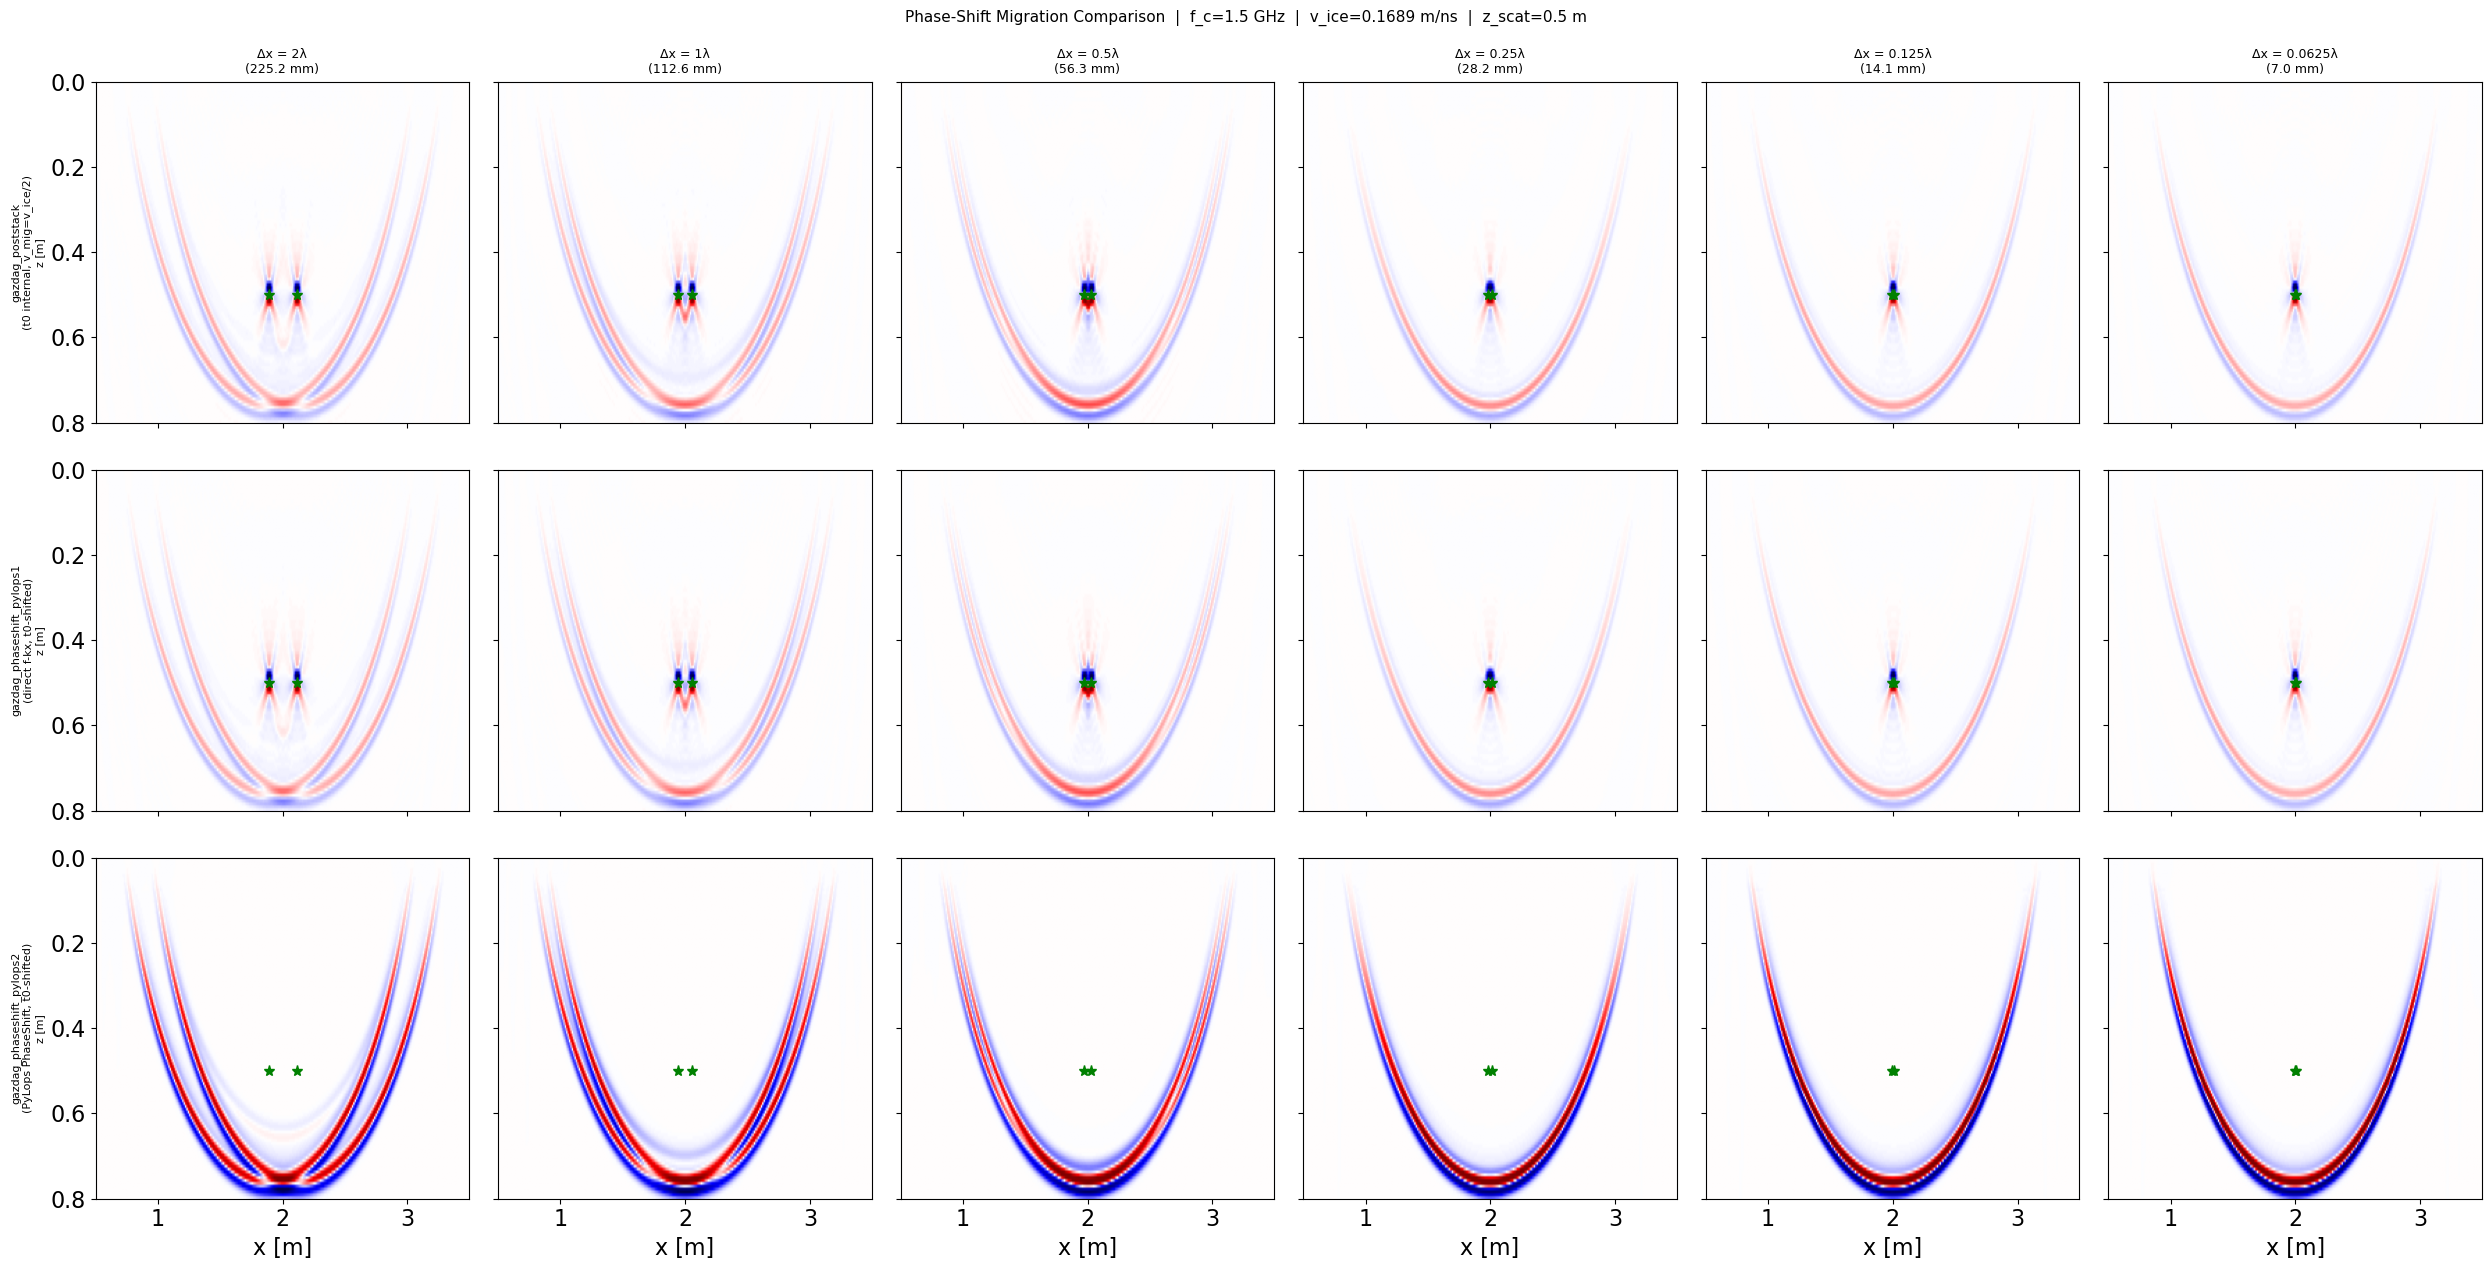

Saved: gallery_phaseshift_comparison.png


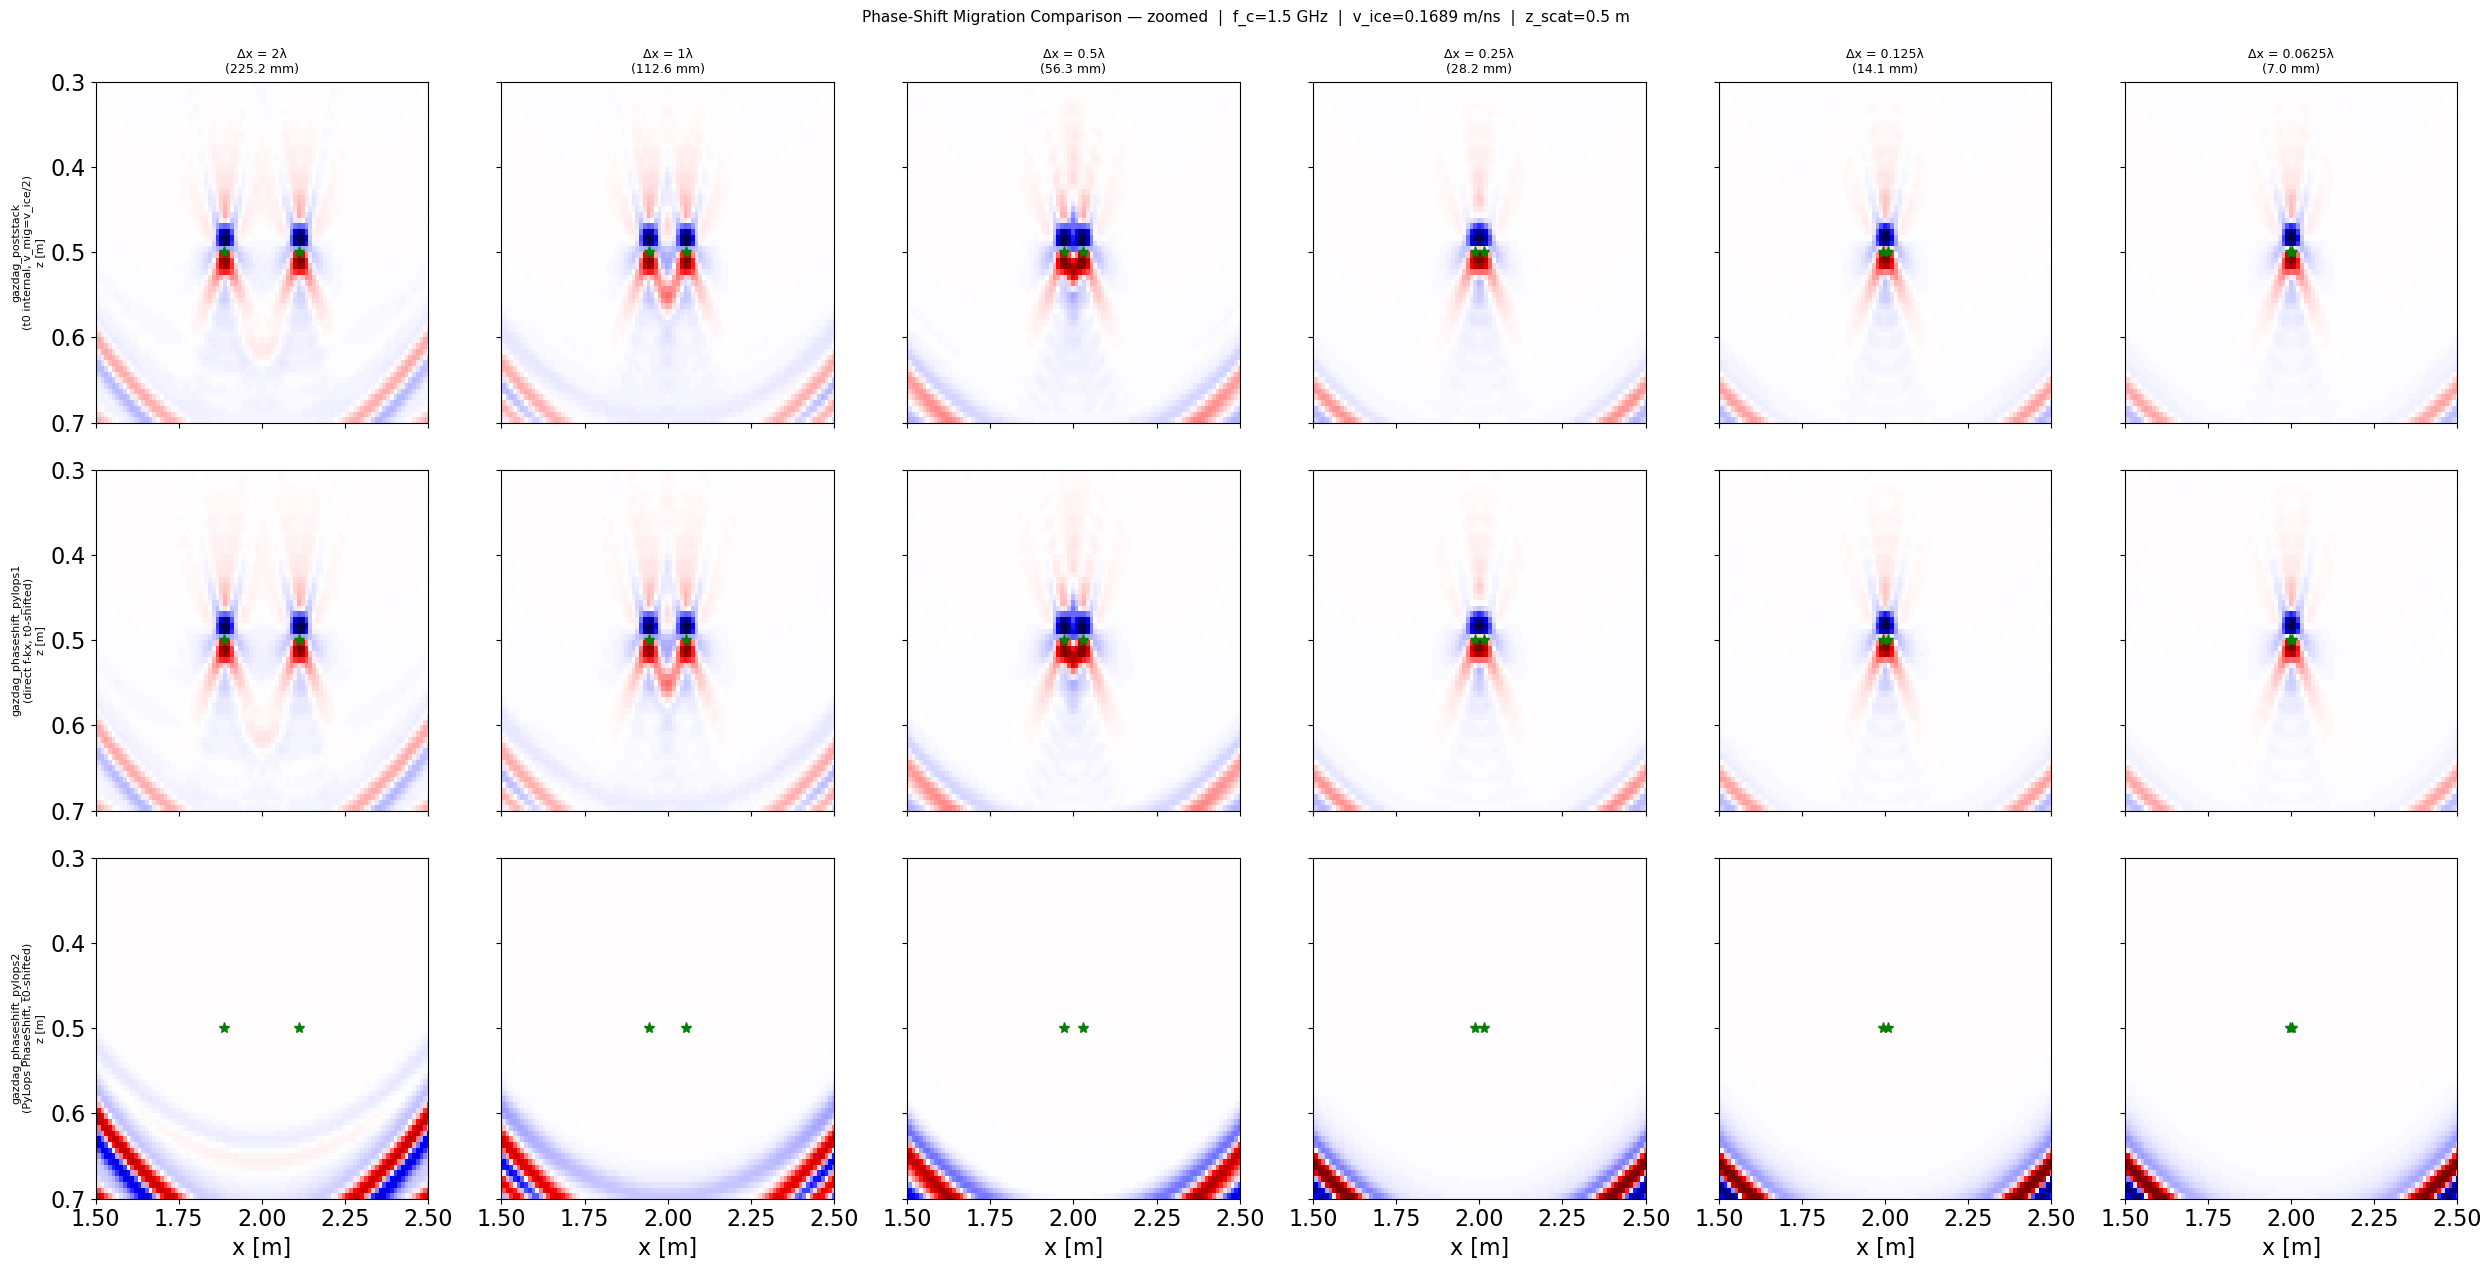

Saved: gallery_phaseshift_comparison_zoomed.png


In [14]:

# gazdag_poststack  : input (n_tr, n_t), uses v_mig=v_ice/2, t0 corrected internally
# gazdag_phaseshift_pylops1/2 : input (n_t, n_tr), uses v_ice (computes v_mig=vel/2 inside),
#                               need t0-shifted data

_t0_samp = int(round(t0_ns / rs_results[0]['dt_ns']))

PS_METHODS = [
    ('ps_gazdag_img',   'gazdag_poststack\n(t0 internal, v_mig=v_ice/2)'),
    ('ps_pylops1_img',  'gazdag_phaseshift_pylops1\n(direct f-kx, t0-shifted)'),
    ('ps_pylops2_img',  'gazdag_phaseshift_pylops2\n(PyLops PhaseShift, t0-shifted)'),
]

for r in rs_results:
    data   = r['bscan_decay_tapered']          # (n_tr, n_t)  â€” for gazdag_poststack
    data_T = data.T.copy()                     # (n_t, n_tr)  â€” for pylops1/2

    # t0 shift for functions that don't handle it internally (shift time axis)
    data_shifted = np.roll(data_T, -_t0_samp, axis=0)
    data_shifted[-_t0_samp:, :] = 0.0

    _t = _time.perf_counter()
    r['ps_gazdag_img'] = gazdag_poststack(
        data, r['dt_ns'], x_traces, v_mig, x_traces, z_img, t0_ns
    )
    print(f'Î”x={r["factor"]:g}Î»  gazdag_poststack         {_time.perf_counter()-_t:.1f} s')

    _t = _time.perf_counter()
    r['ps_pylops1_img'] = gazdag_phaseshift_pylops1(
        data_shifted, x_traces, r['time_ns'], z_img, v_ice
    )
    print(f'Î”x={r["factor"]:g}Î»  gazdag_phaseshift_pylops1  {_time.perf_counter()-_t:.1f} s')

    _t = _time.perf_counter()
    r['ps_pylops2_img'] = gazdag_phaseshift_pylops2(
        data_shifted, x_traces, r['time_ns'], z_img, v_ice
    )
    print(f'Î”x={r["factor"]:g}Î»  gazdag_phaseshift_pylops2  {_time.perf_counter()-_t:.1f} s\n')

print('Phase-shift comparison done.')

# â”€â”€ 3-row comparison gallery â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
_n = len(rs_results)
for xlim, zlim, tag in [
    ((x_traces[0], x_traces[-1]), (z_img[-1], z_img[0]), ''),
    ((1.5, 2.5),                  (0.7, 0.3),            '_zoomed'),
]:
    fig, axes = plt.subplots(3, _n, figsize=(4.2 * _n, 13), sharey='row', sharex='col')
    if _n == 1:
        axes = axes.reshape(3, 1)

    for row, (key, row_label) in enumerate(PS_METHODS):
        for col, r in enumerate(rs_results):
            ax  = axes[row, col]
            img = r[key]
            _p  = np.max(np.abs(img)) * 0.8
            ax.imshow(img, aspect='auto', cmap='seismic',
                      vmin=-_p, vmax=_p,
                      extent=[x_traces[0], x_traces[-1], z_img[-1], z_img[0]],
                      origin='upper')
            ax.set_xlim(*xlim)
            ax.set_ylim(*zlim)
            ax.plot(r['xs1'], z_scat, 'g*', ms=8, zorder=5)
            ax.plot(r['xs2'], z_scat, 'g*', ms=8, zorder=5)
            if row == 0:
                ax.set_title(f'Î”x = {r["factor"]:g}Î»\n({r["delta_m"]*1e3:.1f} mm)', fontsize=9)
            if row == len(PS_METHODS) - 1:
                ax.set_xlabel('x [m]')
            if col == 0:
                ax.set_ylabel(f'{row_label}\nz [m]', fontsize=8)

    zoom_label = ' â€” zoomed' if tag else ''
    fig.suptitle(
        f'Phase-Shift Migration Comparison{zoom_label}'
        f'  |  f_c={f_c_GHz} GHz  |  v_ice={v_ice:.4f} m/ns  |  z_scat={z_scat} m',
        fontsize=11,
    )
    plt.tight_layout()
    out = STUDY_ROOT / f'gallery_phaseshift_comparison{tag}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out.name}')


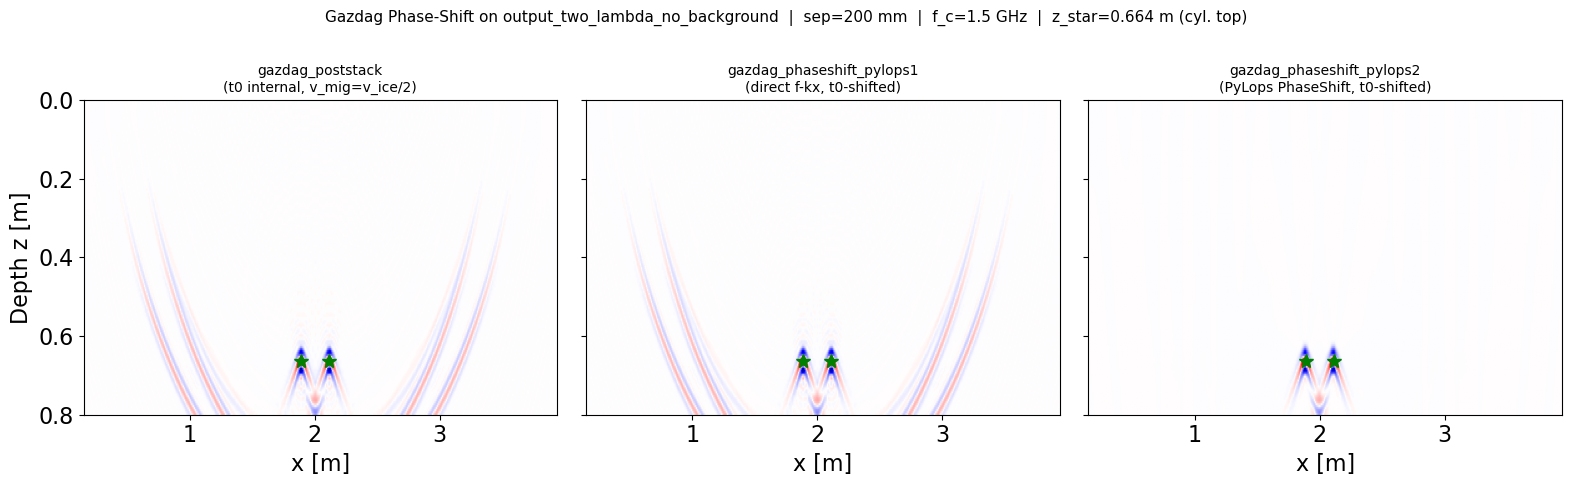

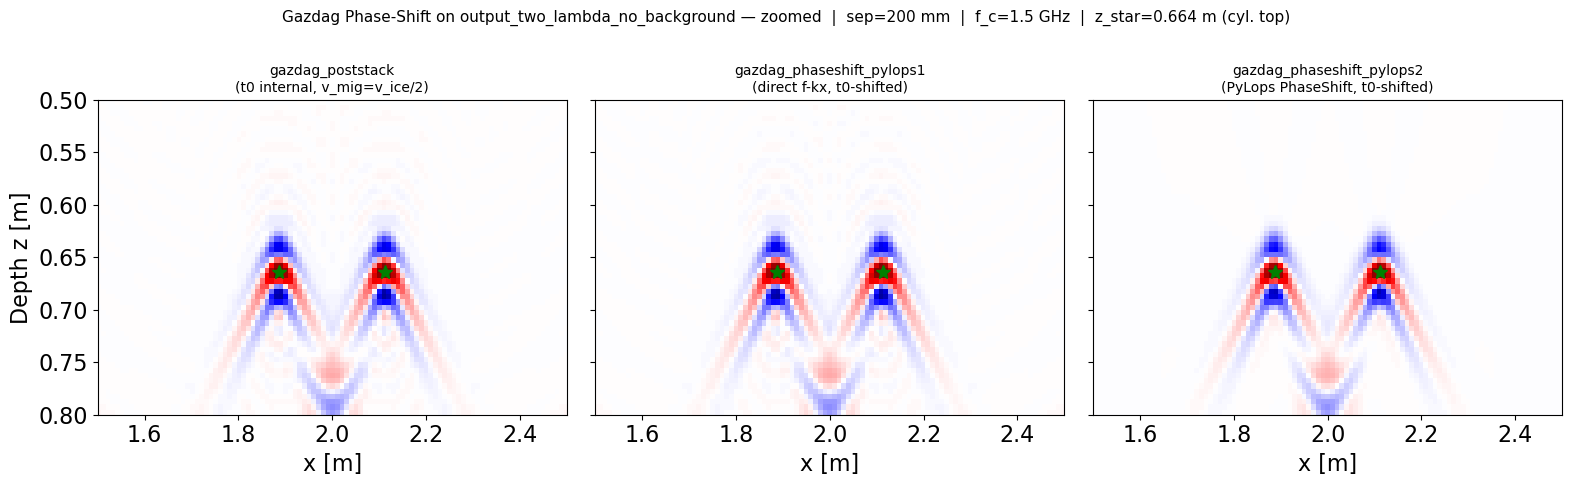

In [189]:
# ── Gazdag on output_two_lambda_no_background ────────────────────────────────
# Reuses _data_tapered, _shifted_2lam, x_traces_2lam, z_img_2lam, z_star_2lam
# from the Kirchhoff cell above.

# gazdag_poststack  : (n_tr, n_t), v_mig=v_ice/2, t0 internal
# gazdag_phaseshift_pylops1/2 : (n_t, n_tr), t0-shifted, uses v_ice

_data_T_2lam    = _data_tapered.T.copy()      # (n_t, n_tr) — unshifted
_shifted_T_2lam = _shifted_2lam.T.copy()      # (n_t, n_tr) — t0-shifted

# ── Run three schemes ─────────────────────────────────────────────────────────
print('── gazdag_poststack ────────────────────────────────────')
_t = _time.perf_counter()
gz_das_2lam = gazdag_poststack(
    _data_tapered, dt_ns_2lam,
    x_traces_2lam, v_mig, x_traces_2lam, z_img_2lam, t0_ns
)
print(f'  Done in {_time.perf_counter()-_t:.1f} s   shape={gz_das_2lam.shape}')

print('── gazdag_phaseshift_pylops1 ───────────────────────────')
_t = _time.perf_counter()
gz_ps1_2lam = gazdag_phaseshift_pylops1(
    _shifted_T_2lam, x_traces_2lam, time_ns_2lam, z_img_2lam, v_ice
)
print(f'  Done in {_time.perf_counter()-_t:.1f} s   shape={gz_ps1_2lam.shape}')

print('── gazdag_phaseshift_pylops2 ───────────────────────────')
_t = _time.perf_counter()
gz_ps2_2lam = gazdag_phaseshift_pylops2(
    _shifted_T_2lam, x_traces_2lam, time_ns_2lam, z_img_2lam, v_ice
)
print(f'  Done in {_time.perf_counter()-_t:.1f} s   shape={gz_ps2_2lam.shape}')

# ── Plot ──────────────────────────────────────────────────────────────────────
_gz_methods_2lam = [
    (gz_das_2lam,  'gazdag_poststack\n(t0 internal, v_mig=v_ice/2)'),
    (gz_ps1_2lam,  'gazdag_phaseshift_pylops1\n(direct f-kx, t0-shifted)'),
    (gz_ps2_2lam,  'gazdag_phaseshift_pylops2\n(PyLops PhaseShift, t0-shifted)'),
]

for xlim, zlim, tag in [
    ((x_traces_2lam[0], x_traces_2lam[-1]), (z_img_2lam[-1], z_img_2lam[0]), ''),
    ((1.5, 2.5),                             (0.8, 0.5),                     '_zoomed'),
]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    for ax, (img, label) in zip(axes, _gz_methods_2lam):
        _p = np.max(np.abs(img)) * 0.8
        ax.imshow(img, aspect='auto', cmap='seismic',
                  vmin=-_p, vmax=_p,
                  extent=[x_traces_2lam[0], x_traces_2lam[-1], z_img_2lam[-1], z_img_2lam[0]],
                  origin='upper')
        ax.set_xlim(*xlim)
        ax.set_ylim(*zlim)
        ax.plot(x_scatterer_1, z_star_2lam, 'g*', ms=10, zorder=5)
        ax.plot(x_scatterer_2, z_star_2lam, 'g*', ms=10, zorder=5)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('x [m]')
    axes[0].set_ylabel('Depth z [m]')
    zoom_label = ' — zoomed' if tag else ''
    fig.suptitle(
        f'Gazdag Phase-Shift on output_two_lambda_no_background{zoom_label}'
        f'  |  sep={scatterer_spacing_m*1e3:.0f} mm  |  f_c={f_c_GHz} GHz'
        f'  |  z_star={z_star_2lam:.3f} m (cyl. top)',
        fontsize=11,
    )
    plt.tight_layout()
    out = STUDY_ROOT / f'gazdag_two_lambda_no_bg{tag}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out.name}')


# Back Propagation (analytical)

# Least Squares Migration

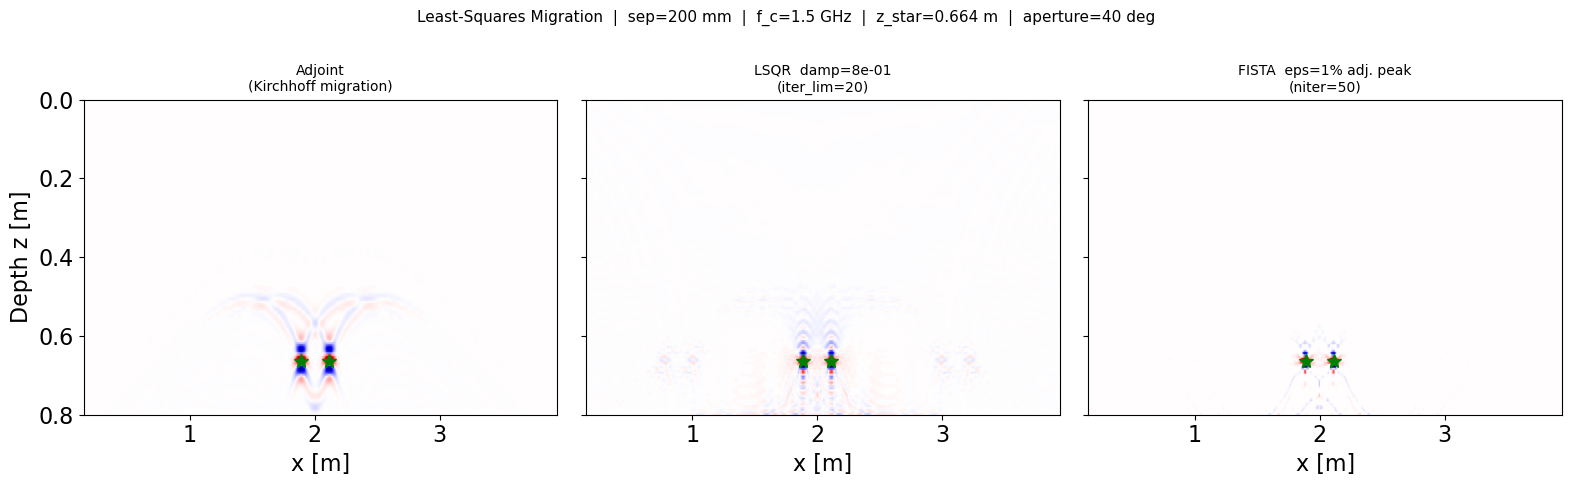

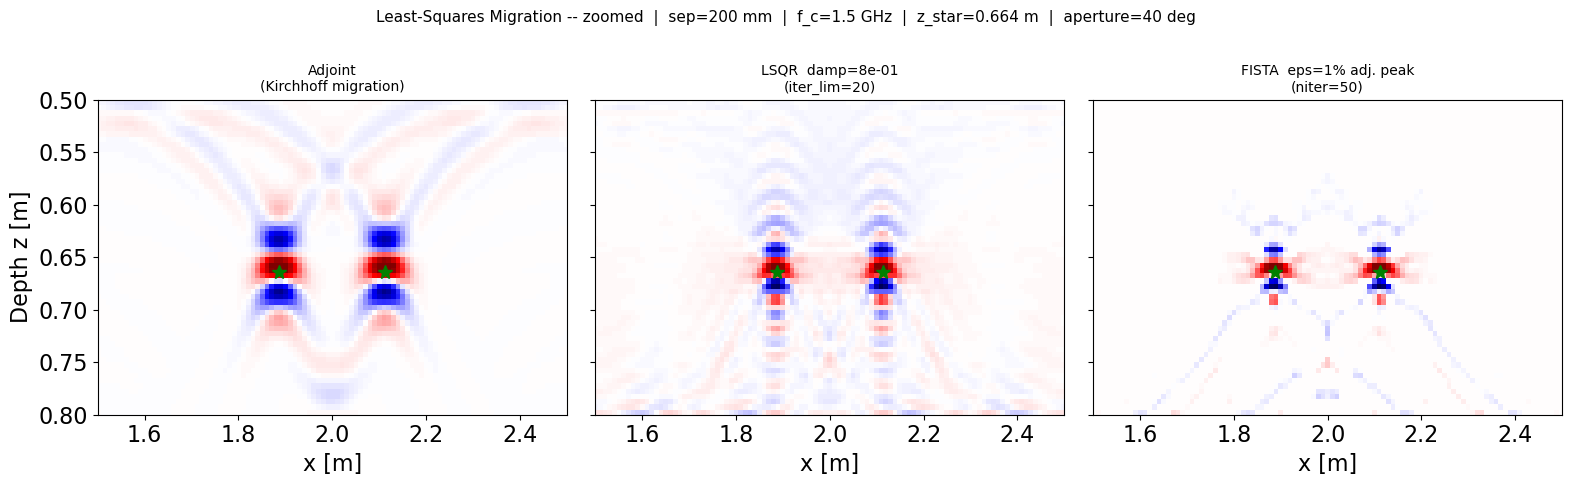

In [26]:
# -- Least-Squares Migration on _shifted_T_2lam ---------------------------
# _shifted_T_2lam shape: (n_t, n_tr) -- t0-shifted + tapered ZO B-scan.
# The Kirchhoff operator expects (n_tr, n_t) row-major, so we work with
# _shifted_2lam (= _shifted_T_2lam.T) for flattening; same underlying data.
#
# Three solvers:
#   (1) Adjoint  -- K^H d              (Kirchhoff migration, baseline)
#   (2) LSQR     -- min ||Km-d||^2 + damp^2||m||^2  (Tikhonov)
#   (3) FISTA    -- min ||Km-d||^2 + eps*||m||_1    (sparse)
#
# Without regularisation LSQR/FISTA fit ALL the data -- including noise and
# components outside the model space -- spreading them as image artefacts.
# eps for FISTA is calibrated relative to the adjoint image peak so it
# remains meaningful regardless of the absolute data amplitude.

import pylops
from scipy.sparse.linalg import lsqr as sp_lsqr
import time as _time

nx_lsm = len(x_traces_2lam)
nz_lsm = len(z_img_2lam)

# -- Build zero-offset Kirchhoff operator ---------------------------------
print('Building Kirchhoff operator ...')
_t = _time.perf_counter()
m_adj_raw, lsm_K = PylopsKirchoffMigration(
    _shifted_2lam, time_ns_2lam, x_traces_2lam,
    v_ice, z_img_2lam,
    f0=f_c_GHz, angleaperture=ANGLE_AP, return_op=True,
)
print(f'  K shape : {lsm_K.shape}   built in {_time.perf_counter()-_t:.1f} s')

# Data vector -- flatten (n_tr, n_t) row-major, same order K was built with
d_lsm = _shifted_2lam.flatten()
print(f'  d_lsm : {d_lsm.shape}')

# -- (1) Adjoint migration  -----------------------------------------------
# PylopsKirchoffMigration already computed K^H d; reuse the returned image.
m_adj_lsm    = m_adj_raw   # (nz, nx)
adjoint_peak = np.max(np.abs(m_adj_lsm))
print(f'\n(1) Adjoint  shape={m_adj_lsm.shape}  peak={adjoint_peak:.3e}')

# -- (2) LSQR with Tikhonov damping ---------------------------------------
# Solves  min ||Km - d||^2 + damp^2 ||m||^2
# Damping suppresses energy in poorly-illuminated model regions and prevents
# the solver from fitting data noise.  Tune: larger -> smoother image.
LSQR_DAMP  = 8e-1    # tune here (try 1e-2 ... 1.0)
LSQR_ITERS = 20

print(f'\n(2) LSQR  damp={LSQR_DAMP:.0e}  iter_lim={LSQR_ITERS}')
_t = _time.perf_counter()
lsqr_result = sp_lsqr(lsm_K, d_lsm, iter_lim=LSQR_ITERS, damp=LSQR_DAMP, show=False)
m_lsqr = lsqr_result[0].reshape(nx_lsm, nz_lsm).T   # (nz, nx)
print(f'  Done in {_time.perf_counter()-_t:.1f} s  stop={lsqr_result[3]}'
      f'  itn={lsqr_result[2]}  residual={lsqr_result[4]:.3e}')

# -- (3) FISTA with L1 sparsity -------------------------------------------
# Solves  min ||Km - d||^2 + eps * ||m||_1
# eps is set as a fraction of the adjoint peak so it scales with amplitude.
# Tune EPS_FRAC: larger -> sparser (stronger artefact suppression).
EPS_FRAC    = 0.01    # tune here (try 0.01 ... 0.2)
FISTA_ITERS = 50
eps_fista   = EPS_FRAC * adjoint_peak

print(f'\n(3) FISTA  eps={eps_fista:.3e} ({EPS_FRAC*100:.0f}% adjoint peak)  niter={FISTA_ITERS}')
_t = _time.perf_counter()
fista_result = pylops.optimization.sparsity.fista(
    lsm_K, d_lsm,
    niter=FISTA_ITERS,
    eps=eps_fista,
    eigsdict={"niter": 30},      # power iterations to estimate Lipschitz constant
    show=False,
)
m_fista = fista_result[0].reshape(nx_lsm, nz_lsm).T   # (nz, nx)
print(f'  Done in {_time.perf_counter()-_t:.1f} s   shape={m_fista.shape}')

# -- Data residuals -------------------------------------------------------
res_adj  = np.linalg.norm(d_lsm - lsm_K @ m_adj_lsm.T.ravel())
res_lsqr = np.linalg.norm(d_lsm - lsm_K @ m_lsqr.T.ravel())
res_fist = np.linalg.norm(d_lsm - lsm_K @ m_fista.T.ravel())
print(f'\n  Data residual ||Km - d||:')
print(f'    Adjoint : {res_adj:.3e}')
print(f'    LSQR    : {res_lsqr:.3e}')
print(f'    FISTA   : {res_fist:.3e}')

# -- Plot -----------------------------------------------------------------
_lsm_panels = [
    (m_adj_lsm, 'Adjoint\n(Kirchhoff migration)'),
    (m_lsqr,    f'LSQR  damp={LSQR_DAMP:.0e}\n(iter_lim={LSQR_ITERS})'),
    (m_fista,   f'FISTA  eps={EPS_FRAC*100:.0f}% adj. peak\n(niter={FISTA_ITERS})'),
]

for xlim, zlim, tag in [
    ((x_traces_2lam[0], x_traces_2lam[-1]), (z_img_2lam[-1], z_img_2lam[0]), ''),
    ((1.5, 2.5),                             (0.8, 0.5),                      '_zoomed'),
]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    for ax, (img, label) in zip(axes, _lsm_panels):
        _p = np.max(np.abs(img)) * 0.8
        ax.imshow(img, aspect='auto', cmap='seismic',
                  vmin=-_p, vmax=_p,
                  extent=[x_traces_2lam[0], x_traces_2lam[-1],
                          z_img_2lam[-1], z_img_2lam[0]],
                  origin='upper')
        ax.set_xlim(*xlim)
        ax.set_ylim(*zlim)
        ax.plot(x_scatterer_1, z_star_2lam, 'g*', ms=10, zorder=5)
        ax.plot(x_scatterer_2, z_star_2lam, 'g*', ms=10, zorder=5)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('x [m]')
    axes[0].set_ylabel('Depth z [m]')
    zoom_label = ' -- zoomed' if tag else ''
    fig.suptitle(
        f'Least-Squares Migration{zoom_label}'
        f'  |  sep={scatterer_spacing_m*1e3:.0f} mm  |  f_c={f_c_GHz} GHz'
        f'  |  z_star={z_star_2lam:.3f} m  |  aperture={ANGLE_AP} deg',
        fontsize=11,
    )
    plt.tight_layout()
    out = STUDY_ROOT / f'lsm_two_lambda_no_bg{tag}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out.name}')


# Back Propagation (gprMax)

# Migration Comparison